In [ ]:
# uncomment this line if you need to install pyphyschemtools
# (remove "# " - don't forget to remove the empty space)
# 1. Force uninstall the old version completely
# !pip uninstall pyNanoMatBuilder -y

# 2. Install the new version with flags that bypass all caches and force a refresh
# !pip install --index-url https://test.pypi.org/simple/ pyNanoMatBuilder==0.9.0 --no-cache-dir --no-deps

# Optional: only necessary if you want to visualize 3D structures directly within the notebook.
# !pip install pyphyschemtools

<div class="rqT", title="📥 README first">

[**Click here: Local (cloning) *vs*. Google Colab**](./colab_vs_local.md)

if you choose a Google Colab cloud session, click on this icon (unless *you are already* in Google Colab):

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rpoteau/pyNanoMatBuilder/blob/main/pyNMB-examples.ipynb)

</div>

pyNanoMatBuilder: parallelism set to 4 threads.



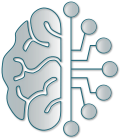

**Environment initialized:** Saturday 23 May 2026, 11:53:35 on localhost.localdomain  
<span style='color: #007a7a; font-weight: bold;'>[OK] Parallel computing ENABLED (4 threads)</span>

pyNMB.__version__='0.12.5'


In [3]:
# # development purpose only. Comment these 2 lines on Google Colab
%load_ext autoreload
%autoreload 2
#------------------------------

##################
# Initialization #
##################
import pyNanoMatBuilder as pyNMB
pyNMB.set_threads(4)
pyNMB.init()
%matplotlib inline
print(f"{pyNMB.__version__=}")

from pyNanoMatBuilder import utils as pyNMBu

# Introduction 

<div class="intro">
    
**pyNanoMatBuilder** is a building tool for generating **3D structures of crystalline nanoparticles (NPs)** of various **shapes** and **sizes**, based on **user-defined compounds** either by name, e.g., "Fe bcc" (cf *data.py* and *cif_database* to see all available compounds and their acronyms) or from your CIF files directly (in the folder *userDefCifs*).

This notebook is a general demonstration of what is possible to do with pyNanoMatBuilder and shows all the shapes you can create, from Wulff constructions to magic number structures. 

Here's the content:
- **Creation of XYZ, CIF files and Jmol scripts** of the nanoparticles from all shape classes (cf. image above). Each class has its own parameters, so do not hesitate to read their documentation.

- **Geometry optimization** using ASE and pyNanoMatBuilder files.

- **More analysis tools** (symmetry, coordination numbers, etc.)

- **Bibliography**

*Note: If you directly want to create a database containing the NP structures and their scattering data, please refer to the `MakeNPsDatabase.ipynb` notebook.*

</div>


## Common Parameters

<div class="intro">
Key parameters available across all nanoparticle classes:

| Parameter | Type | Default | Description |
|-----------|------|------|-------------|
| **`postAnalyzis`** | bool | `True` | Enable detailed analysis including unit cell properties, symmetry analysis, moment of inertia, surface/core informations, precise size informations |
| **`noOutput`** | bool | `False` | Suppress console output |
| **`skipSymmetryAnalyzis`** | bool | `False` | Skip symmetry calculations (useful for faster execution)  (if set to False, requires `postAnalyzis = True`) |
| **`skipFacetInfo`** | bool | `True` | If `False`, computes external facet areas and relative energies in propPostMake  (if set to False, requires `postAnalyzis = True`) <br>The analysis can always be run manually afterwards: `NP.external_facets_info(mode='auto', noOutput=False)`|
| **`skipChiralityCalculation`** | bool | `True` | Skip Osipov–Pickup–Dunmur chirality index calculation  (if set to False, requires `postAnalyzis = True`) |
| **`jmolCrystalShape`** | bool | `True` | Generate Jmol visualization scripts (if set to True, requires `postAnalyzis = True`) |
| **`aseView`** | bool | `False` | Display structure using ASE viewer |
| **`calcPropOnly`** | bool | `False` | Only calculates general properties, if available, without generating atomic coordinates |
| **`thresholdCoreSurface`** | float | `1.0` | Threshold for core/surface atom classification (in &angst;) |

</div>

## How to? Workflow Guides

### Quick usage

<div class="intro">

#### Importation of the necessary classes

First, import a core builder **and** the utility module:

```python
from pyNanoMatBuilder import crystalNPs as cyNP

```

#### Available core builders

The library is organized into specialized classes depending on the crystalline nature and geometric complexity of the nanoparticle you wish to build:

| Class | Abbreviation | Core Shapes & Capabilities |
| :--- | :--- | :--- |
| **`crystalNPs`** | `cyNP` | **Single crystals**: Spheres, ellipsoids, parallelepipeds, hollow shapes, and user- or pre-defined **Wulff constructions** |
| **`platonicNPs`** | `pNP` | **Platonic nanoparticles**: Icosahedron, octahedron, dodecahedron, tetrahedron, and cubes |
| **`archimedeanNPs`** | `aNP` | **Archimedean nanoparticles**: Cuboctahedron, truncated decahedron, truncated octahedron, rhombic dodecahedron, and dihedral rhombic dodecahedron |
| **`johnsonNPs`** | `jNP` | **Johnson nanoparticles & decahedra**: Trigonal/pentagonal bipyramids, Ino decahedron, and Marks decahedron |
| **`otherNPs`** | `oNP` | **Special geometries**: Trigonal platelets and other non-standard architectures |
| **`chiralNPs`** | `chNP` | **Right or Left-handed chiral nanoparticles**: Boerdijk–Coxeter helix |

All currently available shapes are summarized in this figure:

<img src="https://github.com/rpoteau/pyNanoMatBuilder/raw/main/pyNanoMatBuilder/resources/figs/pnmbAvailableStructures.png" style="margin-left:auto; margin-right:auto; display: block; width:1400px" id="img_pNMBAS" alt="Structures available in pyNMB"/> 

#### Generating a Nanoparticle

Instantiate the `pyNMB.Crystal` object to build your structure. **Note that the geometry creation and symmetry analysis are performed immediately upon instantiation.**

```python
# Define parameters
sphere_diameter = [6] # Target diameter in nm
# Instantiate the Crystal object (Au fcc sphere)
AuNP = cyNP.Crystal(
    "Au fcc",
    size=sphere_diameter, 
    shape="sphere", 
    thresholdCoreSurface=1, 
    skipSymmetryAnalyzis=False, 
    noOutput=False
)
```

* **Silent Mode**: Set `noOutput=True` for a silent execution.
* **Performance**: For very large structures (typically > 6 nm), set `skipSymmetryAnalyzis=True` to bypass heavy point-group calculations.

**Available Object Attributes**
Once instantiated, the object (e.g., `AuNP`) contains several key attributes that you can access or save:

| Attribute | Description |
| :--- | :--- |
| **.NP** | An ASE `Atoms` object containing the final shaped nanoparticle. |
| **.NPcs** | The Core/Surface model (where core atoms are labeled as 'No' for visualization). |
| **.cif** | The ASE `Atoms` object of the original unit cell (CrystalNPs module only). |
| **.sc** | The ASE `Atoms` object of the supercell used for shaping (CrystalNPs module only). |
| **.jMolCS** | A string containing the Jmol visualization script for facets (unless `jmolCrystalShape=False`) |

#### Exporting Results

The library provides a unified `write()` utility. It is **mandatory** to use the standard `.xyz`, `.cif`, or `.script` suffixes; otherwise, the utility will not be able to determine the correct format and may fail or lose data.

```python
# Example
pyNMBu.write("coords/SphericalAuNP.xyz", AuNP.NP)
```

* **Atomic Coordinates (`.xyz`)**: Standard geometry file.
* **Core/Surface Model**: A specialized `.xyz` where core atoms are labeled as the element **'No'** (Nobelium). In Jmol, these appear in a distinct magenta color, making the core-shell organization immediately visible.
* **Crystallography (`.cif`)**:
    * **Base Unit Cell**: The original crystal structure used as the building block.
    * **Supercell**: The expanded cell used for shaping the NP (automatically calculated based on the target size).

#### External Jmol Visualization

To visualize surface faceting and crystalline organization:

1.  Open Jmol and load your resulting `.xyz` or `.cif` file.
2.  In the Jmol console, load the generated visualization script:
    ```bash
    script "path_to_folder/your_np_name.script"
    ```
    *This script overlays the geometric "envelope" (facets) onto your atomic structure.*

<div class="rqE">
    
**Note on Core/Surface ID**: The 'No' (Nobelium) label is a visualization trick. If you are using these files for DFT calculations or MD simulations, remember to convert the 'No' atoms back to their original element (e.g., 'Au') using a text editor or the ASE `atoms.set_chemical_symbols()` method.
</div>


#### Internal Visualization

If you are working in a Jupyter Notebook or Google Colab, you can visualize the nanoparticle internally (without Jmol) by two ways
- either by using the `molView` class of the `pyphyschemtools` library. This provides an interactive 3D view directly in your cell output

```python
!pip install pyphyschemtools # if necessary
from pyphyschemtools import molView
m = molView(AuNP.NP,source="ase", w=600,h=600)
```

<br>
<div class="rqE">

`molView` is unable to interpret jmol scripts.
</div>

- by setting `aseView=True` (default is False). For crystal-based shapes, the unitcell, the supercell, and the resulting facetted single crystal will all be displayed

```python
AuNP = cyNP.Crystal(
    "Au fcc",
    size=[3], 
    shape="sphere", 
    thresholdCoreSurface=1, 
    skipSymmetryAnalyzis=False, 
    noOutput=False,
    aseView=True,
)
```

</div>

### Detailed documentation

<div class="intro">
    
You can either enter `cyNP.Crystal?` to see the docstring or consult the [on-line API reference](https://pynanomatbuilder.readthedocs.io/en/latest/).
</div>

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP
cyNP.Crystal?

# Crystal structure-based shapes

## Quick usage

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP


# Define parameters
sphere_diameter = [4] # Target diameter in nm
# Instantiate the Crystal object (Au fcc sphere)
AuNP = cyNP.Crystal(
    "Au fcc",
    size=sphere_diameter,
    shape="sphere",
    thresholdCoreSurface=1,
    skipSymmetryAnalyzis=False,
    noOutput=False
)

# AuNP.propPostMake(noOutput=False)

# Save the results in various formats
# The 'write' utility automatically creates the 'coords/' directory, if it does not exist
pyNMBu.write("coords/SphericalAuNP.xyz", AuNP.NP)                # Main coordinates
pyNMBu.write("coords/SphericalAuNP_CoreSurface.xyz", AuNP.NPcs)  # Core/surface model
pyNMBu.write("coords/SphericalAuNP.script", AuNP.jMolCS)         # JMOL visualization script

# # Save unitcells
pyNMBu.write("coords/SphericalAuNP_uc.cif", AuNP.cif)            # The base unitcell
pyNMBu.write("coords/SphericalAuNP_sc.cif", AuNP.sc)             # The supercell

# Internal visualization
from pyphyschemtools import molView
AuNPc = AuNP.NP.copy()
AuNPc.center()
# molView.view_grid([AuNP.cif, AuNP.NP, AuNPc], n_cols = 3, source="ase", titles= ["unitcell", "NP centered at O", "NP centered in the middle of the unit cell"], w=600, h =600, detect_BondOrders=False)

pyNMB.centertxt("unitcell", size=14, weight="bold")
mv = molView(AuNP.cif, source="ase")
pyNMB.centertxt("NP centered at O", size=14, weight="bold")
mv = molView(AuNP.NP, source="ase", h=600, w=600)
pyNMB.centertxt("NP centered in the middle of the unit cell", size=14, weight="bold")
mv = molView(AuNPc, source="ase", h=600, w=600)
pyNMB.centertxt("NP with core/surface highlight", size=14, weight="bold")
AuNP.NPcs.center()
mv = molView(AuNP.NPcs, source="ase", h=600, w=600)
pyNMB.centertxt("Supercell used for shaping a sphere", size=14, weight="bold")
AuNP.sc.center()
mv = molView(AuNP.sc, source="ase", h=600, w=600)

## Spheres

<div class="intro">
    
**The size parameter for the sphere is simply the diameter [d] in nm. Few examples are presented.**

</div>

### Au NPs

In [ ]:
# Imports
from pyNanoMatBuilder import crystalNPs as cyNP


# Let's make a sphere with a diameter of ~ 4 nm (4 nm will be the target size, the measured size will be slightly different due to compound cristalline organization)
sphere_diameter = [4] # diameter in nm
AuNP = cyNP.Crystal("Au fcc",
                    size = sphere_diameter,
                    shape = "sphere",
                    thresholdCoreSurface = 1,
                    skipSymmetryAnalyzis = True,
                    noOutput = False
                   )

# Save the files (XYZ, JMOL script, CIF) of the NP and also the core/surface model
pyNMBu.write("coords/SphericalAuNP.xyz", AuNP.NP) # XYZ file with the 
pyNMBu.write("coords/SphericalAuNP_CoreSurface.xyz", AuNP.NPcs) # XYZ file of the core/surface model
AuNP.NP.center()
pyNMBu.write("coords/SphericalAuNP.cif", AuNP.NP) # CIF file
pyNMBu.write("coords/SphericalAuNP.script", AuNP.jMolCS) # JMOL script if postAnalyzis and jmolCrystalShape are True (they are by default)
pyNMBu.write("coords/SphericalAuNP2.cif", AuNP.cif) # CIF file


### Ru

In [ ]:
# Imports
from pyNanoMatBuilder import crystalNPs as cyNP


# Let's make a Ruthenium sphere of a diameter ~ 5 nm
RuNP = cyNP.Crystal("Ru hcp",
                    shape= "sphere",
                    size = [5]
                   ) # Other parameters set as default, see documentation

# Save the files( XYZ, JMOL script, CIF) and the core/surface model
pyNMBu.write("coords/SphericalRuNP.xyz", RuNP.NP) 
pyNMBu.write("coords/SphericalRuNP.cif", RuNP.cif) 
pyNMBu.write("coords/SphericalRuNP_sc.cif", RuNP.sc) 
RuNP.NP.center()
pyNMBu.write("coords/SphericalRuNP.cif", RuNP.NP)
pyNMBu.write("coords/SphericalAuNP_sc.cif", RuNP.sc)
pyNMBu.write("coords/SphericalRuNP.script", RuNP.jMolCS) # JMOL script
pyNMBu.write("coords/SphericalRuNP_CoreSurface.xyz", RuNP.NPcs)  

### TiO2

In [ ]:
# Imports
from pyNanoMatBuilder import crystalNPs as cyNP


# Let's make a TiO2 sphere of a diameter ~ 3 nm
TiO2rNP = cyNP.Crystal("TiO2 rutile",
                       size= [3],
                       thresholdCoreSurface = 1,
                       skipSymmetryAnalyzis = False
                      )

# Save the files( XYZ, JMOL script, CIF) and the core/surface model
pyNMBu.write("coords/SphericalTiO2rNP_cif.cif", TiO2rNP.cif)
pyNMBu.write("coords/SphericalTiO2ruNP_sc.cif", TiO2rNP.sc)
TiO2rNP.NP.center()
pyNMBu.write("coords/SphericalTiO2rNP.cif", TiO2rNP.NP)
pyNMBu.write("coords/SphericalTiO2rNP.xyz", TiO2rNP.NP)
pyNMBu.write("coords/SphericalTiO2rNP_CoreSurface.xyz", TiO2rNP.NPcs)
pyNMBu.write("coords/SphericalTiO2rNP.script", TiO2rNP.jMolCS)

### load an external cif file
**You can try it out with your own CIF files, just place them in the userDefCifs folder**

In [ ]:
# imports
from pyNanoMatBuilder import crystalNPs as cyNP


# This time let's use CIF files from the user (put your CIF files in userDefCifs)
Fe2NNP = cyNP.Crystal(userDefCif="./userDefCifs/Fe2N-zeta-1668016.cif",
                      shape = "sphere",
                      size = [2],
                      skipSymmetryAnalyzis = True
                     )

# Save the files( XYZ, JMOL script, CIF) and the core/surface model
pyNMBu.write("coords/SphericalFe2N_NP_cif.cif", Fe2NNP.cif)
pyNMBu.write("coords/SphericalFe2N_NP_sc.cif", Fe2NNP.sc)
pyNMBu.write("coords/SphericalFe2N_NP.xyz", Fe2NNP.NP)
pyNMBu.write("coords/SphericalFe2N_NP_CoreSurface.xyz", Fe2NNP.NPcs)
pyNMBu.write("coords/SphericalFe2N_NP.script", Fe2NNP.jMolCS)
Fe2NNP.NP.center()
pyNMBu.write("coords/SphericalFe2N_NP.cif", Fe2NNP.NP)

## Ellipsoids

### Au

**The size parameters of the ellipsoids are the three diameter [a, b, c] in nm.**

In [ ]:
# Imports
from pyNanoMatBuilder import crystalNPs as cyNP


# size = [a,b,c] : a, b, c being the diameters in the 3 directions
AuNP = cyNP.Crystal("Au fcc",
                    shape='ellipsoid',
                    size= [4, 7, 9],
                    thresholdCoreSurface=2,
                    skipSymmetryAnalyzis=False)

pyNMBu.write("coords/EllipsoidalAuNP.xyz", AuNP.NP)
pyNMBu.write("coords/EllipsoidalAuNP.script", AuNP.jMolCS)

### NaCl

In [ ]:
# Imports
from pyNanoMatBuilder import crystalNPs as cyNP


NaClNP = cyNP.Crystal("NaCl",
                      shape='ellipsoid',
                      size= [4, 7, 9], # size=[a,b,c] : a, b, c being the diameters in the 3 directions
                      thresholdCoreSurface=2,
                      skipSymmetryAnalyzis=False)

pyNMBu.write("coords/EllipsoidalNaClNP.xyz", NaClNP.NP)
NaClNP.get_ellipsoid_analysis(mode="vertices")
NaClNP.get_ellipsoid_analysis(mode="planes")
NaClNP.get_ellipsoid_analysis(mode="all")

pyNMBu.write("coords/EllipsoidalNaClNPcs.xyz", NaClNP.NPcs)
pyNMBu.write("coords/EllipsoidalNaClNP.script", NaClNP.jMolCS)

## Parallelepipeds
**The size parameters are [a, b, c] the lengths of the parallelepiped in nm. The parallelepiped can be constructed using:**
- **"xyz"**: Cartesian coordinates (orthogonal axes)
- **"abc"**: Crystallographic unit cell vectors (may have non-90° angles)

<div class="rq">

*Note: When using "abc" mode, the cell vectors follow the compound's unit cell geometry. For non-orthogonal cells, the final dimensions may not be accurately calculated - this is currently under development.*
</div>




### Au fcc

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP


# Size = [a, b, c] the lengths in nm
AuNP = cyNP.Crystal("Au fcc",
                    shape='pppd',
                    size = [2.2,4,6],
                    buildPPD='xyz',
                    skipFacetInfo=False,
                    thresholdCoreSurface=2)

# Save the XYZ/CIF files and JMOL script
pyNMBu.write("coords/AuParallelepiped.xyz", AuNP.NP)
pyNMBu.write("coords/AuParallelepiped_sc.cif", AuNP.sc)
pyNMBu.write("coords/AuParallelepiped_sc.xyz", AuNP.sc)
pyNMBu.write("coords/AuParallelepiped_CoreSurface.xyz", AuNP.NPcs)
pyNMBu.write("coords/AuParallelepiped.script", AuNP.jMolCS)

AuNP.NP.center()
pyNMBu.write("coords/AuParallelepiped.cif", AuNP.NP)

### hcp Ru

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP

RuNP = cyNP.Crystal("Ru hcp",
                    shape = 'pppd',
                    size = [2, 2, 5],
                    buildPPD = 'abc',
                    thresholdCoreSurface = 2,
                    skipSymmetryAnalyzis = False,
                    skipFacetInfo=False,
                    noOutput = False)

# Save the XYZ/CIF files and JMOL script
pyNMBu.write("coords/RuParallelepiped.xyz", RuNP.NP)
pyNMBu.write("coords/RuParallelepiped_sc.cif", RuNP.sc)
pyNMBu.write("coords/RuParallelepiped_CoreSurface.xyz", RuNP.NPcs)
pyNMBu.write("coords/RuParallelepiped.script", RuNP.jMolCS)

RuNP.NP.center()
pyNMBu.write("coords/RuParallelepiped.cif", RuNP.NP)


## Wulff construction

### Brief documentation

<div class="intro">
    
The Wulff construction generates nanoparticles whose shape minimizes the total
surface energy. Two modes are available:

#### Mode 1 — Energy-based (`eSurfacesWulff`)

Provide surface planes and their energies. The shape is determined by the
relative energies — the most stable (lowest energy) faces grow largest.

```python
from pyNanoMatBuilder import crystalNPs as cyNP

AuNP = cyNP.Crystal("Au fcc",
                shape='Wulff',
                surfacesWulff=[[1,1,1], [1,0,0], [1,1,0]],
                eSurfacesWulff=[60, 80, 90],  # one energy per plane
                sizesWulff=[4],               # target size in nm (single value)
                symWulff=False)
```

- `surfacesWulff`: list of Miller indices, one per plane.
- `eSurfacesWulff`: list of surface energies (arbitrary units), one per plane.
  Lower energy → larger face. Values can be taken from databases such as
  [The Materials Project](https://next-gen.materialsproject.org/materials/).
- `sizesWulff`: **single value** — the target nanoparticle size in nm,
  measured in the direction of the most stable face (lowest energy).
  The distance to all other truncation planes is scaled automatically
  from the energy ratios.

#### Mode 2 — Distance-based (`sizesWulff`)

Provide surface planes and the explicit distance from the center to each
truncation plane.

```python
from pyNanoMatBuilder import crystalNPs as cyNP

AuNP = cyNP.Crystal("Au fcc",
                    shape='Wulff',
                    surfacesWulff=[[1,1,1], [1,0,0], [1,1,0]],
                    sizesWulff=[2, 4, 3],  # one distance per plane, in nm
                    symWulff=False)
```

- `surfacesWulff`: list of Miller indices, one per plane.
- `sizesWulff`: **one value per plane** — the distance in nm from the center
  to each truncation plane. Larger value → plane is further from center →
  larger face.
- `eSurfacesWulff`: not used in this mode (`None`).

#### Symmetry option (`symWulff`)

`symWulff` controls whether pyNanoMatBuilder automatically generates all
crystallographically equivalent planes from a single representative:

```python
symWulff=True   # recommended for standard shapes
```
You only need to provide **one plane per family** — pyNanoMatBuilder uses the
crystal space group to generate all equivalent planes automatically.
For example, providing `[1,1,1]` automatically adds
`[-1,1,1]`, `[1,-1,1]`, `[1,1,-1]`, etc.

```python
symWulff=False  # required for anisotropic shapes (nanorods, etc.)
```
All planes must be listed **explicitly**. Use this when you want different
energies or distances for planes that are crystallographically equivalent
but physically distinct — for example, assigning different energies to
`[0,0,1]` and `[1,0,0]` to drive elongation along one axis.

#### Note on `sizesWulff`

> The size parameter behaves differently depending on the mode:
> - **Energy mode** (`eSurfacesWulff` provided): `sizesWulff` is a
>   **single value** — the overall target size in nm.
> - **Distance mode** (no `eSurfacesWulff`): `sizesWulff` is a
>   **list** — one distance per plane in nm.

</div>

### List of the pre-defined Wulff shapes in the `data.WulffShapes.WSdf` pandas dataframe

In [2]:
import pandas as pd
from pyNanoMatBuilder import data
from pyNanoMatBuilder.data import WulffShapes as WS

pd.set_option('display.max_colwidth', 250)
display(WS.WSdf)
pd.set_option('display.max_colwidth', 50) ## revert

,full name,lattice system,Bravais lattice,planes,apply symmetry,relative energies,MOI for size,comment
cube,cube,cubic,"bcc, fcc","[[1, 0, 0]]",True,[1.0],cube,cutting length from the cubes vertex c = 0
trcube,truncated cube,cubic,fcc,"[[1, 0, 0], [1, 1, 1]]",True,"[1.2071067811865475, 1.6825219847121646]",cube,r3 = sqr((17+12sqr(2))/3)/2; r8 = (1+sqr(2))/3
cubo,cuboctahedron,cubic,fcc,"[[1, 0, 0], [1, 1, 1]]",True,"[0.7071067811865476, 0.8164965809277259]",cube,cutting length from the cubes vertex c = 0.5; r3 = sqr(6)/3; r4 = sqr(2)/2
Oh,octahedron,cubic,fcc,"[[1, 1, 1]]",True,[1.0],Oh,cutting length from the cubes vertex c = 1
trOh,truncated octahedron,cubic,fcc,"[[1, 0, 0], [1, 1, 1]]",True,"[1.4142135623730951, 1.224744871391589]",sphere,r4 = sqr(2); r6 = sqr(6)/2
Td,tetrahedron,cubic,fcc,"[[1, 1, 1], [1, -1, -1], [-1, -1, 1], [-1, 1, -1]]",False,"[1.0, 1.0, 1.0, 1.0]",Td,NaN
dicoTd,deltoidal icositetrahedron,cubic,fcc,"[[2, 1, 1]]",True,[1.0],dicoTd,10.1063/1.4790368
bccrDD,rhombic dodecahedron,cubic,bcc,"[[1, 1, 0]]",True,[1.0],bccrDD,NaN
trbccrDD,truncated rhombic dodecahedron,cubic,bcc,"[[1, 1, 0], [1, 1, 1]]",True,"[1.0, 1.0]",bccrDD,NaN
ttrbccrDD,tetratruncated rhombic dodecahedron,cubic,bcc,"[[1, 1, 0], [0, 0, 1]]",True,"[1.0, 1.0]",bccrDD,"chamfered cube or Goldberg polyhedron, r4=(3+4*sqr(3))/6, r6 = sqr(2)*(3+2*sqr(3))/6, 10.1039/c6dt00343e"


### fcc Au

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP


# You can define yourself the surface planes and their energies
sfW = [[1,1,1],[0,0,1]]
eW = [-3.0,-4]

# Define the target size between the truncated surface planes (~ 4 nm)
szW=[8]

AuNP = cyNP.Crystal("Au fcc",
                    shape='Wulff',
                    surfacesWulff=sfW,
                    eSurfacesWulff=eW,
                    sizesWulff=szW,
                    thresholdCoreSurface=0.5,
                    skipSymmetryAnalyzis= False,
                    postAnalyzis=True,
                    jmolCrystalShape=True,
                    skipFacetInfo=False,
                    aseView= False)

# Save the XYZ, CIF files and JMOL script
pyNMBu.write("coords/AuWulff_sc.cif", AuNP.sc)
pyNMBu.write("coords/AuWulff.xyz", AuNP.NP)
# pyNMBu.write("coords/AuWulff.script", AuNP.jMolCS)

AuNP.NP.center()
pyNMBu.write("coords/AuWulff.cif", AuNP.NP)

### hcp Ru

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP


# Define the target size between the truncated surface planes (~ 6 nm)
szW = [4]

RuNP = cyNP.Crystal("Ru hcp",
                    shape='Wulff: hcpsph2',
                    # surfacesWulff=sfW,
                    # eSurfacesWulff=eW,
                    sizesWulff=szW,
                    threshold=1e-3,
                    thresholdCoreSurface=2,
                    postAnalyzis= True,
                    jmolCrystalShape=True,
                    skipFacetInfo=False,
                    skipSymmetryAnalyzis=False,
                    aseView= False)

# Save the XYZ/CIF files and JMOL script
pyNMBu.write("coords/RuWulff_sc.cif", RuNP.sc)
pyNMBu.write("coords/RuWulff.xyz", RuNP.NP)
pyNMBu.write("coords/RuWulff.cif", RuNP.NP)
pyNMBu.write("coords/RuWulff.script", RuNP.jMolCS)
RuNP.NP.center()
pyNMBu.write("coords/RuWulff.cif", RuNP.NP)

### Pre-defined Wulff shapes
No need to give the planes and their energies this time.

#### Cuboctahedron

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP


# Define the target size between the truncated surface planes (~ 5 nm)
szW = [5]

# The surface planes and energies are automatically retrieved via data.py
TestNP = cyNP.Crystal("Au fcc",
                      shape='Wulff: cubo',
                      sizesWulff=szW,
                      threshold=0.1,
                      thresholdCoreSurface=2,
                      postAnalyzis=True,
                      jmolCrystalShape=True,
                      aseView= False,
                      noOutput=False,
                      skipSymmetryAnalyzis=False,
                      skipFacetInfo=False,
                     )

# Save the XYZ/CIF files and JMOL script
pyNMBu.write("coords/TestWulff_sc.cif", TestNP.sc)
pyNMBu.write("coords/TestWulff.xyz", TestNP.NP)
pyNMBu.write("coords/TestWulff.script", TestNP.jMolCS)
TestNP.NP.center()
pyNMBu.write("coords/OhFeBeta.cif", TestNP.NP)

#### Octahedron of gold

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP


# Define the target size between the truncated surface planes (~ 4 nm)
szW = [4]

# The surface planes and energies are automatically retreived via data.py
TestNP = cyNP.Crystal("Au fcc",
                      shape='Wulff: Oh',
                      sizesWulff=szW,
                      threshold=0.1,
                      thresholdCoreSurface=2,
                      postAnalyzis=True,
                      jmolCrystalShape=True,
                      aseView= False,
                      noOutput=False,
                      skipSymmetryAnalyzis=True,
                      skipFacetInfo=False,
                     )

# Save the XYZ/CIF files and JMOL script
pyNMBu.write("coords/TestWulff_sc.cif", TestNP.sc)
pyNMBu.write("coords/TestWulff.xyz", TestNP.NP)
pyNMBu.write("coords/TestWulff.script", TestNP.jMolCS)
TestNP.NP.center()
pyNMBu.write("coords/TestWulff.cif", TestNP.NP)

#### Rhombicuboctahedron (bcc)

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP


# Define the target size between the truncated surface planes (~ 4 nm)
szW = [4.7]

# The surface planes and energies are automatically retreived via data.py
FeNP = cyNP.Crystal("Fe bcc",
                    shape='Wulff : rhcubo',
                    sizesWulff=szW,
                    threshold=1e-3,
                    thresholdCoreSurface=2,
                    postAnalyzis= False,
                    jmolCrystalShape=True,
                    aseView= False)

# Save the XYZ/CIF files and JMOL script
pyNMBu.write("coords/FeWulff_sc.cif", FeNP.sc)
pyNMBu.write("coords/FeWulff_sc.xyz", FeNP.sc)
pyNMBu.write("coords/FeWulff.xyz", FeNP.NP)
pyNMBu.write("coords/FeWulff.cif", FeNP.NP)
pyNMBu.write("coords/FeWulff.script", FeNP.jMolCS)
FeNP.NP.center()
pyNMBu.write("coords/FeWulff.cif", FeNP.NP)

## Wires

<div class="intro">
    
**Key Parameters:**
- **directionWire** `[h, k, l]`: Miller indices defining the wire axis (e.g., `[1, 0, 0]`)
- **nRotWire**: Number of sides in the wire's cross-section (e.g., `4` for square, `6` for hexagonal)
- **size** `[diameter, length]`: Wire dimensions in nm (e.g., `[2, 8]`)
- **refPlaneWire** `[h, k, l]`: Miller indices of the reference plane, rotated around the growth direction to form the cross-section
- **pbc**: Periodic boundary conditions (True/False)
</div>



### fcc crystal (Au): parallepipedic wire

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP


# Define the shape parameters of the wire: growth direction, dimensions = [diameter, length], 
# refPlane =   Miller indices of the reference plane, which is rotated around "directionWire"
# nRot =  Number of sides in the wire's cross-section
direction=[1,0,0]
dim = [2,6]
refPlane = [0,0,1]
nRot = 4 # square cross-section

AuWire = cyNP.Crystal("Au fcc",
                      shape='wire',
                      size=dim,
                      directionWire=direction,
                      nRotWire=nRot,
                      refPlaneWire=refPlane,
                      pbc=False,
                      skipSymmetryAnalyzis=False,
                      skipFacetInfo=False,
                      threshold=3)

# Save the XYZ/CIF files and JMOL script
pyNMBu.write("coords/AuWire.xyz", AuWire.NP)
pyNMBu.write(f"coords/AuWire.script", AuWire.jMolCS)


### hcp crystal (Co): hexagonal wire

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP


# Define the shape parameters of the wire: growth direction, dimensions = [diameter, length], 
# refPlane =   Miller indices of the reference plane, which is rotated around "directionWire"
# nRot =  Number of sides in the wire's cross-section
direction = [0,0,1] 
dim = [2,8] 
refPlane = [1,0,0] 
nRot = 6 # hexagonal cross section

CoWire = cyNP.Crystal("Co hcp",
                      shape='wire',
                      size=dim,
                      directionWire=direction,
                      nRotWire=nRot,
                      refPlaneWire=refPlane,
                      pbc=False,
                      aseView= False,
                      skipSymmetryAnalyzis=False,
                      skipFacetInfo=False,
                      threshold=3)

# Save the XYZ/CIF files and JMOL script
pyNMBu.write("coords/CoWire.xyz", CoWire.NP)
pyNMBu.write("coords/CoWire.script", CoWire.jMolCS)
CoWire.NP.center()
pyNMBu.write("coords/CoWire.cif", CoWire.NP)
CoWire.NPcs.center()
pyNMBu.write("coords/CoWire_CoreSurface.cif", CoWire.NPcs)

### hcp crystal (Ru)

#### [0,0,1] RuNW with pbc and refPlane = (1 0 0) = [2 1 0] direction

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP


# Define the shape parameters of the wire: growth direction, dimensions = [diameter, length], 
# refPlane =   Miller indices of the reference plane, which is rotated around "directionWire"
# nRot =  Number of sides in the wire's cross-section
direction = [0,0,1] 
dim = [2,5]
refPlane = [1,0,0] 
nRot = 6 # hexagonal cross section

RuWire = cyNP.Crystal("Ru hcp",
                      shape='wire',
                      size=dim,
                      directionWire=direction,
                      nRotWire=nRot,
                      refPlaneWire=refPlane,
                      pbc= True,
                      aseView= False,
                      skipSymmetryAnalyzis=True,
                      skipFacetInfo=False,
                     )

# Save the XYZ/CIF files and JMOL script
pyNMBu.write("coords/RuWire.xyz", RuWire.NP)
pyNMBu.write("coords/RuWire.script", RuWire.jMolCS)

RuWire.NP.center()
pyNMBu.write("coords/RuWire.cif", RuWire.NP)
RuWire.NPcs.center()
pyNMBu.write("coords/RuWire_CoreSurface.cif", RuWire.NPcs)

from pyphyschemtools import molView
m=molView(RuWire.NP, 'ase', supercell=(1,1,2), style='cpk', cpk_scale=2.0, w=500, h=1000)

#### [1,0,0] RuNW with pbc and refPlane = [0,0,1]


In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP


# Define the shape parameters of the wire: growth direction, dimensions = [diameter, length], 
# refPlane =   Miller indices of the reference plane, which is rotated around "directionWire"
# nRot =  Number of sides in the wire's cross-section
direction = [1,0,0]
dim = [3,6] 
refPlane = [0,0,1]
nRot = 6 # hexagonal cross section

RuWire = cyNP.Crystal("Ru hcp",
                      shape='wire',
                      size=dim,
                      directionWire=direction,
                      nRotWire=nRot,
                      refPlaneWire=refPlane,
                      pbc=True,
                      aseView= False,
                      skipSymmetryAnalyzis=True,
                     )

# Save the XYZ/CIF files and JMOL script
pyNMBu.write("coords/RuWire.xyz", RuWire.NP)
pyNMBu.write("coords/RuWire.script", RuWire.jMolCS)

RuWire.NPcs.center()
pyNMBu.write("coords/RuWire_CoreSurface.cif", RuWire.NPcs)
RuWire.NP.center()
pyNMBu.write("coords/RuWire.cif", RuWire.NP)

### fcc crystal (Au)

#### [1,1,1] AuNW with pbc and refPlane = [2,1,1], *i.e.* a wrong truncation plane

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP


pyNMB.centerTitle(f"Au nanowire with wrong truncation reference plane and pbc")

# Define the shape parameters of the wire: growth direction, dimensions = [diameter, length], 
# refPlane =   Miller indices of the reference plane, which is rotated around "directionWire"
# nRot =  Number of sides in the wire's cross-section
direction = [1,1,1]
dim = [2,4]
refPlane = [2,1,1]
nRot = 8

AuWire = cyNP.Crystal("Au fcc",
                      shape='wire',
                      size=dim,
                      directionWire=direction,
                      nRotWire=nRot,
                      refPlaneWire=refPlane,
                      pbc=True,
                      skipSymmetryAnalyzis=True,
                      skipFacetInfo=False,
                     )

# Save the XYZ and CIF files
pyNMBu.write("coords/AuWire.xyz", AuWire.NP)
pyNMBu.write("coords/AuWire.cif", AuWire.NP)
pyNMBu.write("coords/AuWire_CoreSurface.cif", AuWire.NPcs)

#### [1,1,1] Au nanowire with good truncation reference plane. Play with pbc True or False...

In [ ]:

from pyNanoMatBuilder import crystalNPs as cyNP

# Define the shape parameters of the wire: growth direction, dimensions = [diameter, length], 
# refPlane =   Miller indices of the reference plane, which is rotated around "directionWire"
# nRot =  Number of sides in the wire's cross-section
direction=[1,1,1]
dim = [2,6]
refPlane = [0,1,-1]
nRot = 4

AuWire = cyNP.Crystal("Au fcc",
                      shape='wire',
                      size=dim,
                      directionWire=direction,
                      nRotWire=nRot,
                      refPlaneWire=refPlane,
                      pbc=True,
                      skipSymmetryAnalyzis=False,
                      threshold=3
                     )

# Save the XYZ/CIF files
pyNMBu.write("coords/AuWire.xyz", AuWire.NP)
pyNMBu.write("coords/AuWire.cif", AuWire.NP)
pyNMBu.write("coords/AuWire_CoreSurface.cif", AuWire.NPcs)
pyNMBu.write("coords/AuWire.script", AuWire.jMolCS)

### Cylinder

**Key Parameters:**
- **directionCylinder** `[h, k, l]`: Miller indices defining the wire axis (e.g., `[1, 0, 0]`)
- **size** `[diameter, length]`: Cylinder dimensions in nm (e.g., `[2, 8]`)
- **pbc**: Periodic boundary conditions (True/False)


**The cylinder is defined by its size = [diameter, length] and its growth direction [h, k, l]**

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP


# Define the cylinder parameters
dim = [3, 12] # diameter and length in nm
direction = [1, 1, 1] # growth direction

AuCylinder = cyNP.Crystal("Au fcc",
                          shape= 'cylinder',
                          size=dim,
                          directionCylinder=direction,
                          pbc=False,
                          aseView= False,
                          skipSymmetryAnalyzis=True,
                          noOutput=False
                         )

# Save the XYZ/CIF files and JMOL script
pyNMBu.write("coords/Aufcccylinder.xyz", AuCylinder.NP)
pyNMBu.write("coords/Aufcccylinder.script", AuCylinder.jMolCS)
AuCylinder.get_ellipsoid_analysis(mode='vertices')
AuCylinder.get_ellipsoid_analysis(mode='surface')
AuCylinder.get_ellipsoid_analysis(mode='all')

AuCylinder.NPcs.center()
pyNMBu.write("coords/Aufcccylinder_CoreSurface.xyz", AuCylinder.NPcs)
AuCylinder.NP.center()
pyNMBu.write("coords/Aufcccylinder.cif", AuCylinder.NP)

<div class="rqE">

pbc in a general orientation is not an easy problem...
</div>

## Miscellaneous

### Change the atoms and size of the reference unit cell

<div class="intro">

In this example, the ruthenium hcp unitcell - that contains 2 Ru atoms - is used as a basis to build an hcp alloy with alternating Au/Ru planes, with the nearest neighbour bond length defined as 2.6 Å
</div>

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP

CuAuNP = cyNP.Crystal("Ru hcp",
                      shape='Wulff: cube',
                      sizesWulff=[2],
                      threshold=1e-3,
                      thresholdCoreSurface=2,
                      scaleDmin2=2.6,
                      setSymbols2=['Au','Cu'],
                      postAnalyzis=True,jmolCrystalShape=True,
                      noOutput=True
                     )
pyNMBu.write("coords/CuAualloy.xyz", CuAuNP.NP)

### Wulff constructions with the ase.cluster.cubic class

In [ ]:
import numpy as np
import ase
from ase.io import write
from ase.visualize import view

import pyNanoMatBuilder.utils as pyNMBu

import ase
from ase.cluster.cubic import FaceCenteredCubic

lc = 3.82
surfaces = [(0,0,1),(1, 1, 1)]
layers = [4,4]
atoms = FaceCenteredCubic('Ru',
                          surfaces,
                          layers,
                          latticeconstant=lc)
view(atoms)

# Magic number clusters and nanoparticles

## Magic numbers

In [ ]:
from pyNanoMatBuilder import data

from pyNanoMatBuilder import visualID as vID
import numpy as np
import pandas as pd

pyNMBd = data.pyNMBdata()
print("clusters variable in data.py = ",pyNMBd.clusters)

pyNMBu.centerTitle("Single cluster type")
nmax = 20
cluster = 'regIco'
sizes = np.array(range(1,nmax+1))
print(f"Magic numbers for {cluster} = ",pyNMBu.magicNumbers(cluster,sizes))

print()
pyNMBu.centerTitle("Store all magic numbers in a dataframe")
nmax = 12
sizes = np.array(range(1,nmax+1))
mndf = pd.DataFrame()
for c in pyNMBd.clusters:
    mn = pyNMBu.magicNumbers(c,sizes)
    mndf[c] = mn
mndf.set_index(sizes,inplace=True)
display(mndf)

## Platonic NPs

<div class="intro">

[Platonic solids on Wikipedia](https://en.wikipedia.org/wiki/Platonic_solid)

[Platonic solids on Wolfram MathWorld](https://mathworld.wolfram.com/PlatonicSolid.html)
</div>

<div class="intro">

**The platonic module is dedicated to magic number structures: regular icosahedrons, tetrahedrons, octahedrons, dodecahedrons, and cubes.**

This module follows the same logic as the crystal module, but uses different size parameters depending on the construction geometry. Consult the documentation for each class to understand the specific parameter definitions:

**Size Parameters by Shape**

| Parameter | Shapes | Description |
|-----------|--------|-------------|
| **nOrder** | Octahedron, Cube | Number of nested shells in a Russian-doll configuration (imbrication level) |
| **nShell** | Icosahedron, Dodecahedron | Number of concentric shells built outward from the center |
| **nLayer** | Tetrahedron | Number of atomic layers, equivalently the number of atoms along an edge |

The distinction reflects different construction principles: **nOrder** represents structures built as nested polyhedra (like Russian dolls), while **nShell** describes structures grown layer-by-layer from a central core. Both **nOrder** and **nShell** correspond to the number of atomic layers along an edge, but their conceptual frameworks differ based on the geometric construction.

*Note: Standard platonic structures are fully implemented with accurate structural information. Specialized variants (double icosahedrons and tetrahedral helices) are functional but provide approximate dimensional data—these features are under active development.*

</div>

### Regular icosahedra

In [ ]:
# If you need to look at the documentation
# from pyNanoMatBuilder import platonicNPs as pNP
# pNP.regIco?

In [ ]:
from pyNanoMatBuilder import platonicNPs as pNP


# Define the number of shells
nshells = 5
ico = pNP.regIco("Ag",
                 2.7,
                 nshells,
                 skipSymmetryAnalyzis=False,
                 noOutput=False
                )
pyNMBu.write("coords/ico.xyz", ico.NP)
pyNMBu.write("coords/ico_CoreSurface.xyz", ico.NPcs)
pyNMBu.write("coords/ico.script", ico.jMolCS)

### Extension: double icosahedron

**The double icosahedron cluster: ongoing work**

A specific structure that can be found in the litterature, for example :
- https://link.springer.com/article/10.1007/s100530170149 (more theory)
- https://pubs.acs.org/doi/pdf/10.1021/acs.nanolett.3c04435 (more experimental)

*Note: the dimension informations are accurate for the initial icosahedron only.*

In [ ]:
from pyNanoMatBuilder import platonicNPs as pNP


# Define the number of shells
dico = pNP.regIco("Au",
                 2.7 ,
                 3,
                 double_ico = True,
                 skipSymmetryAnalyzis=False,
                 noOutput=False
                )
pyNMBu.write("coords/dico.xyz", dico.NP)
pyNMBu.write("coords/dico_CoreSurface.xyz", dico.NPcs) # algorithm struggling when concave ... still good to visualize the surface planes 
pyNMBu.write(f"coords/dico.script", dico.jMolCS)

### Regular fcc tetrahedra

<div class="intro">

[Wikipedia](https://en.wikipedia.org/wiki/Tetrahedron)
</div>

In [ ]:
# If you need to look at the documentation
# from pyNanoMatBuilder import platonicNPs as pNP
# pNP.regfccTd?

In [ ]:
from pyNanoMatBuilder import platonicNPs as pNP


# Let's make a regular gold tetrahedron of 7 layers 
Td = pNP.regfccTd("Au",
                  2.7,
                  7,
                  noOutput=False)

# Save the XYZ/CIF files
pyNMBu.write("coords/Td.xyz", Td.NP)
pyNMBu.write("coords/Td_CoreSurface.xyz", Td.NPcs)
pyNMBu.write(f"coords/Td.script", Td.jMolCS)

### Extension: the Boerdijk-Coxeter helix

**Helix of tetrahedrons: the Boerdijk-Coxeter helix**

Again, it is a specific structure, if you want to learn more about it, go to the */Docs/helices/* folder. 

The new parameter is simply :             
- n_tetrahedrons (int): The  number of tetrahedrons in the optionnal helix.
  
*Notes: the dimensions are for one tetrahedron only, and the total number of atoms given by JMOL is also false (because atoms from the reflected plane are counted twice).
Please refer to "Helix Informations". 
Developements ongoing.*

In [ ]:
from pyNanoMatBuilder import platonicNPs as pNP


# Let's make an helix of 20 tetrahedron of 5 layers each
bch = pNP.regfccTd("Au",
                  2.7,
                  nLayer = 5, 
                  n_tetrahedrons = 20,
                  postAnalyzis= True,
                  skipSymmetryAnalyzis= True,
                  noOutput=False,
                 )

# Save the XYZ/CIF files
pyNMBu.write("coords/bch.xyz", bch.NP)
pyNMBu.write("coords/bch_CoreSurface.xyz", bch.NPcs)
pyNMBu.write(f"coords/bch.script", bch.jMolCS)

### Regular dodecahedra

<div class="intro">

[Wikipedia](https://en.wikipedia.org/wiki/Dodecahedron)
</div>

In [ ]:
# If you need to look at the documentation
# from pyNanoMatBuilder import platonicNPs as pNP
# pNP.regDD?

In [ ]:
from pyNanoMatBuilder import platonicNPs as pNP
# 

# Define the number of shells:
nshells = 5
rdd = pNP.regDD("Au",
                2.7,
                nShell = nshells,
                noOutput=False)

# Save the XYZ/CIF files and the JMOL script
pyNMBu.write("coords/rdd.xyz", rdd.NP)
pyNMBu.write("coords/rdd_CoreSurface.xyz", rdd.NPcs)
pyNMBu.write(f"coords/rdd.script", rdd.jMolCS)

### Regular fcc octahedra

<div class="intro">

[Wikipedia](https://en.wikipedia.org/wiki/Octahedron)
</div>

In [ ]:
# If you need to look at the documentation
# from pyNanoMatBuilder import platonicNPs as pNP
# pNP.regfccOh?

In [ ]:
from pyNanoMatBuilder import platonicNPs as pNP


# Define nOrder (the number of atomic layers along an edge)
fccOh = pNP.regfccOh("Au",
                     2.7,
                     5,
                     noOutput=False,
                     skipSymmetryAnalyzis=True
                    )

# Save the XYZ/CIF files
pyNMBu.write("coords/fccOh.xyz",fccOh.NP)
pyNMBu.write("coords/fccOh_CoreSurface.xyz",fccOh.NPcs)
pyNMBu.write("coords/fccOh.script",fccOh.jMolCS)

### Cubes

<div class="intro">

- [Wikipedia]()
- [Wolfram mathworld](https://mathworld.wolfram.com/Cube.html)
</div>

####  fcc cubes

In [ ]:
# If you need to look at the documentation
# from pyNanoMatBuilder import platonicNPs as pNP
# pNP.cube?

In [ ]:
# from pyNanoMatBuilder import platonicNPs as pNP
# 

# Define nOrder (the number of atomic layers along an edge)
fcc = pNP.cube('fcc',
               'Au',
               Rnn= 2.7,
               nOrder = 2,
               noOutput=False,
               skipSymmetryAnalyzis = True,
               postAnalyzis= True
              ) 

# Save the XYZ/CIF files
pyNMBu.write("coords/fcccube.xyz", fcc.NP)
pyNMBu.write("coords/fcccube_CoreSurface.xyz", fcc.NP)
pyNMBu.write("coords/fcccube.script", fcc.jMolCS)

#### bcc cubes

In [ ]:
from pyNanoMatBuilder import platonicNPs as pNP


# Create a bcc cube of nOrder = 7
bcc = pNP.cube('bcc',
               'Fe',
               Rnn= 2.47,
               nOrder = 7,
               noOutput=False,
               skipSymmetryAnalyzis = False
              )

# Save the XYZ file
pyNMBu.write("coords/bcccube.xyz", bcc.NP)
pyNMBu.write("coords/bcccube_CoreSurface.xyz", bcc.NP)
pyNMBu.write("coords/bcccube.script", bcc.jMolCS)

### Extension: hollow cubes

<div class='intro'>
    
To create the hollow cube, first create a regular cube using the **cube** class, then create the hollow using the `hollow_shapes()` fu nction with the following parameters:
- **full_cube:** instance of the cube class
- **nOrder_hollow:** nOrder of the hollow

*Note: nOrder of the hollow must be inferior to the nOrder of the cube.*
</div>

In [ ]:
from pyNanoMatBuilder import platonicNPs as pNP


# Create the full cube
full_cube=pNP.cube('fcc',
                   'Au',
                   Rnn=2.7,
                   nOrder=9,
                   noOutput=True,
                   skipSymmetryAnalyzis = True)

# Create its hollow counterpart
hollow_cube= pNP.hollow_shapes(full_cube = full_cube,
                               nOrder_hollow = 7,
                               noOutput=False,
                               skipSymmetryAnalyzis = True) 

# Save the files
pyNMBu.write("coords/fcccube.xyz", full_cube.NP)
pyNMBu.write("coords/fcchollowcube.xyz", hollow_cube.NP)
pyNMBu.write("coords/hollowcube.script", hollow_cube.jMolCS)

## Archimedean NPs

This class uses the `platonicNPs` module to generate the parent structures, then applies a truncation of ~33% (chosen to approximate more stable shapes).  
As a result, the size parameters follow the same definitions as in the Platonic classes.

**Size parameters (same convention as Platonic NPs)**

| Parameter | Shape(s) | Meaning |
|---|---|---|
| **nOrder** | Truncated octahedron, truncated cube | Number of nested shells in a Russian-doll configuration (imbrication level) |
| **nShell** | Cuboctahedron | Number of concentric shells built outward from the center |
| **nLayer** | Truncated tetrahedron | Number of atomic layers, equivalently the number of atoms along an edge |



In [ ]:
from pyNanoMatBuilder import platonicNPs as pNP
from pyNanoMatBuilder import archimedeanNPs as aNP

### Cuboctahedron

<div class="intro">

- [Wikipedia](https://en.wikipedia.org/wiki/Cuboctahedron)
- [Wolfram mathworld](https://mathworld.wolfram.com/Cuboctahedron.html)
</div>


In [ ]:
# # If you want to read the documentation
# from pyNanoMatBuilder import archimedeanNPs as aNP
# aNP.fccCubo?

In [ ]:
from pyNanoMatBuilder import archimedeanNPs as aNP


# Let's make a cuboctahedron of 5 shells (number of atomic layers along an edge)
cubo = aNP.fccCubo("Au",
                   2.7,
                   5,
                   noOutput=False,
                   postAnalyzis= True
                  )

# Save the XYZ files and the JMOL script
pyNMBu.write("coords/cubo.xyz", cubo.NP)
pyNMBu.write("coords/cubo_CoreSurface.xyz", cubo.NPcs)
pyNMBu.write("coords/cubo.script", cubo.jMolCS)

### Truncated fcc tetrahedron

<div class="intro">

- [Wikipedia](https://en.wikipedia.org/wiki/Truncated_tetrahedron)
- [Wolfram mathworld](https://mathworld.wolfram.com/TruncatedTetrahedron.html)
</div>

In [ ]:
# If you want to read the documenation
#from pyNanoMatBuilder import archimedeanNPs as aNP
# aNP.fccTrTd?

In [ ]:
from pyNanoMatBuilder import archimedeanNPs as aNP


# Let's make a truncated tetrahedron from an tetrahedron of 16 shells
trTd = aNP.fccTrTd("Au",
                   2.7,
                   7,
                   noOutput=False,
                   postAnalyzis= True
                  )

# Save the XYZ files and JMOL script
pyNMBu.write("coords/Td-2truncate.xyz", trTd.NP0) # the initial tetrahedron
pyNMBu.write("coords/trTd.xyz", trTd.NP) # the truncated one
pyNMBu.write("coords/trTd_CoreSurface.xyz", trTd.NPcs)
pyNMBu.write("coords/trTd.script", trTd.jMolCS)

### Truncated fcc octahedron

In [ ]:
# If you want to read the documentation
# from pyNanoMatBuilder import archimedeanNPs as aNP
# aNP.fccTrOh?

In [ ]:
# from pyNanoMatBuilder import archimedeanNPs as aNP
# 

# Let's mahe a truncated octahedron from an octahedron of order = 12
trOh = aNP.fccTrOh("Au",
                   2.7,
                   12,
                   noOutput=False,
                   skipSymmetryAnalyzis=True
                  )

# Save the XYZ files
pyNMBu.write("coords/trOh_original.xyz", trOh.NP0) # the initial octahedron
pyNMBu.write("coords/trOh.xyz", trOh.NP) # the truncated one
pyNMBu.write("coords/trOh.script", trOh.jMolCS)

### Truncated fcc cube (in progress)

<div class="intro">

[Wikipedia](https://en.wikipedia.org/wiki/Truncated_cube)

[Wolfram MathWorld](https://mathworld.wolfram.com/TruncatedCube.html)
</div>
<br>
<div class="rq">

Regular truncated fcc cube is not comptabible with bcc, fcc or hcp. Rather use Wulff constructions
</div>

In [ ]:
# if you want to read the documentation
# from pyNanoMatBuilder import archimedeanNPs as aNP
# aNP.fccTrCube?

In [ ]:
from pyNanoMatBuilder import archimedeanNPs as aNP


trCube = aNP.fccTrCube("Au",
                       2.7,
                       6,
                       noOutput=False,
                       calcPropOnly=False
                      )


## Catalan NPs

<div class="intro">
    
**Size parameter**

The **bcc rhombic dodecahedron** and **fcc dihedral rhombic dodecahedron** are constructed using a size parameter that defines the extent of the structure:

| Parameter | Description |
|-----------|-------------|
| **nShell** |  Number of concentric shells built outward from the center  |

</div>


### Bcc rhombic dodecahedron (not working)


<div class="intro">

- [Wikipedia](https://en.wikipedia.org/wiki/Rhombic_dodecahedron)
- [Wolfram mathworld](https://mathworld.wolfram.com/RhombicDodecahedron.html)
</div>

In [ ]:
# If you want to read the documentation
# from pyNanoMatBuilder import catalanNPs as cNP
# cNP.bccrDD?

In [ ]:
from pyNanoMatBuilder import catalanNPs as cNP


# Let's make a rhombic dodecahedron of 5 shells
bccrdd = cNP.bccrDD("Fe",
                    2.47,
                    8,
                    noOutput=False,
                    skipSymmetryAnalyzis= True
                   )

# Save the XYZ files and JMOL script
pyNMBu.write("coords/bccrdd.xyz", bccrdd.NP)
pyNMBu.write("coords/bccrdd_CoreSurface.xyz", bccrdd.NPcs)
pyNMBu.write("coords/bccrdd.script", bccrdd.jMolCS)

### Fcc dihedral rhombic dodecahedron

In [ ]:
# If you want to read the documentation
# from pyNanoMatBuilder import catalanNPs as cNP
# cNP.fccdrDD?

In [ ]:
from pyNanoMatBuilder import catalanNPs as cNP


# Let's make a dihedral rhombic dodecahedron of 5 shells
fccdrdd = cNP.fccdrDD("Au",
                      2.7,
                      8,
                      skipSymmetryAnalyzis = False,
                      noOutput=False
                      )

# Save the XYZ files and jmol script
pyNMBu.write("coords/fccdrdd.xyz", fccdrdd.NP)
pyNMBu.write("coords/fccdrdd_CoreSurface.xyz", fccdrdd.NPcs)
pyNMBu.write("coords/fccdrdd.script", fccdrdd.jMolCS)

## Johnson NPs

<div class="intro">

[Wikipedia](https://en.wikipedia.org/wiki/Johnson_solid)

[Wolfram MathWorld](https://mathworld.wolfram.com/JohnsonSolid.html)
</div>

<div class="intro">

This class defines **two shape families**:

**1. fcc trigonal bipyramid**

Size parameter:

| Parameter | Meaning |
|---|---|
| **nLayerTd** | Number of atomic layers in **one** tetrahedral pyramid. The full bipyramid has **2 × nLayerTd** layers (top + bottom). |

---

**2. pentagonal bipyramids, including elongated and truncated variants**

Size parameters:

| Parameter | Meaning |
|---|---|
| **sizeP** | Number of layers in the pentagonal cross-section (equivalently, number of bonds per pentagonal edge). |
| **sizeE** | Number of layers along the elongated height direction (number of bonds per elongated edge). |
| **Marks** | Truncation depth per pentagonal edge, expressed as number of atoms removed. The total truncation at a full vertex is **2 × Marks**. |

</div>

### Fcc trigonal bipyramid

In [ ]:
# If you want to read the documentation
# from pyNanoMatBuilder import johnsonNPs as jNP
# jNP.fcctbp?

In [ ]:
from pyNanoMatBuilder import johnsonNPs as jNP


# Let's make a trigonal bipyramid from singular pyramids of 6 layers each  (= 12 layers in the bipyramid)
tbp = jNP.fcctbp("Au",
                 2.7,
                 17,
                 noOutput=False,
                 skipSymmetryAnalyzis = True
                )

# Save the XYZ files and jmol script
pyNMBu.write("coords/Td-5tpb.xyz", tbp.NP0) # one pyramid
pyNMBu.write("coords/tbp.xyz", tbp.NP) # the bipyramid
pyNMBu.write("coords/tbp_CoreSurface.xyz", tbp.NPcs)
pyNMBu.write("coords/tbp.script", tbp.jMolCS)

### Pentagonal bipyramids (decahedron) and elongated bipyramids

In [ ]:
# If you want to read the documentation
# from pyNanoMatBuilder import johnsonNPs as jNP
# jNP.epbpyM?

#### Decahedron

In [ ]:
from pyNanoMatBuilder import johnsonNPs as jNP


########################################################################################
# 1. Make a regular dodecahedron of 5 shells per edges
########################################################################################
sizeOfThePentagone = 5
sizeOfTheElongatedPart = 0
MarksTruncation = 0

ppy1 = jNP.epbpyM("Au",
                  2.7,
                  sizeP = sizeOfThePentagone,
                  sizeE = sizeOfTheElongatedPart,
                  Marks = MarksTruncation,
                  skipSymmetryAnalyzis= True,
                  thresholdCoreSurface=1,
                  noOutput=False
                 )

pyNMBu.write("coords/ppy1.xyz", ppy1.NP)
pyNMBu.write("coords/ppy1_CoreSurface.xyz", ppy1.NPcs)
pyNMBu.write("coords/ppy1.script", ppy1.jMolCS)


#### Ino decahedron

In [ ]:
########################################################################################
# 2. Make a dodecahedron of 5 shells with an elongation of 8 shells along its height
########################################################################################
sizeOfThePentagone = 5
sizeOfTheElongatedPart = 8
MarksTruncation = 0

ppy2 = jNP.epbpyM("Au",
                  2.7,
                  sizeP = sizeOfThePentagone,
                  sizeE = sizeOfTheElongatedPart,
                  Marks = MarksTruncation,
                  skipSymmetryAnalyzis= True,
                  thresholdCoreSurface=1,
                  noOutput=False
                 )

pyNMBu.write("coords/ppy2.xyz", ppy2.NP)
pyNMBu.write("coords/ppy2_CoreSurface.xyz", ppy2.NPcs)
pyNMBu.write("coords/ppy3.script", ppy2.jMolCS)

#### Marks decahedron

In [ ]:
########################################################################################
# 3. Make a dodecahedron of 10 shells with a Marks truncation of 3 atoms per edge (= 6 atoms per vertices)
########################################################################################
sizeOfThePentagone = 10
sizeOfTheElongatedPart = 0
MarksTruncation = 3

ppy3 = jNP.epbpyM("Au",
                  2.7,
                  sizeP = sizeOfThePentagone,
                  sizeE = sizeOfTheElongatedPart,
                  Marks = MarksTruncation,
                  skipSymmetryAnalyzis= True,
                  noOutput=False
                 )

pyNMBu.write("coords/ppy3.xyz", ppy3.NP)
pyNMBu.write("coords/ppy3_CoreSurface.xyz", ppy3.NPcs)
pyNMBu.write("coords/ppy3.script", ppy3.jMolCS)

#### "Elongated" Marks decahedron

In [ ]:
########################################################################################
# 4. Combine 2. and 3. : Make dodecahedron of 10 shells with a elongation of 5 shells
# and a Marks truncation of 3 atoms per edge (= 6 atoms per vertices)
########################################################################################
sizeOfThePentagone = 10
sizeOfTheElongatedPart = 5
MarksTruncation = 3

ppy4 = jNP.epbpyM("Au",
                  2.7,
                  sizeP =sizeOfThePentagone,
                  sizeE = sizeOfTheElongatedPart,
                  Marks = MarksTruncation,
                  skipSymmetryAnalyzis= True,
                  noOutput=False
                 )

pyNMBu.write("coords/ppy4.xyz", ppy4.NP)
pyNMBu.write("coords/ppy4_CoreSurface.xyz", ppy4.NPcs)
pyNMBu.write("coords/ppy4.script", ppy4.jMolCS)

## Other NPs

For now, only the platelet exists. It is built by adding two truncated tetrahedrons to create a bipyramid, then potentially adding shells between the two pyramids.

Size parameter:

| Parameter | Meaning |
|---|---|
| **nLayerTd** | Number of layers (bonds per edge) of the two tetrahedrons used to create the platelet. This value will define the edge length of the final platelet; the number of layers of the platelet will be `nLayerTd + 1`. |
| **nLayer** | The number of layers kept for each tetrahedron (not counting the twin plane). This value will define the thickness of the platelet; the number of layers in the final platelet will be `nLayer * 2`. |


In [ ]:
from pyNanoMatBuilder import otherNPs as oNP

### Platelets

#### Triangular fcc platelets 

In [ ]:
# If you want to read the documentation
# from pyNanoMatBuilder import otherNPs as oNP
#  oNP.fcctpt?

In [ ]:
from pyNanoMatBuilder import otherNPs as oNP
import pyNanoMatBuilder.utils as pyNMBu

# Let's make the double truncated tetrahedron with: 
lengthEdge = 15 # LENGTH OF THE PLATELET : 15 layers (bonds per edge) for each tetrahedrons, the final edge will have 16 layers (bonds per edge)
nshells = 3 # HEIGHT OF THE PLATELET : 3 shells kept for each tetrahedrons, the final number of shells will be 6 
tpt = oNP.fcctpt("Fe",
                 2.47,
                 lengthEdge,
                 nshells,
                 noOutput=False,
                 skipSymmetryAnalyzis=True,
                )

# Save the XYZ files and JMOL script
pyNMBu.write("coords/tbp_4tpt.xyz", tpt.NP0)
pyNMBu.write("coords/tpt.xyz", tpt.NP)
pyNMBu.write("coords/tpt_CoreSurface.xyz", tpt.NPcs)
pyNMBu.write("coords/tpt.script", tpt.jMolCS)


# Chiral NPs

## Boerdijk–Coxeter helix

In [ ]:
from pyNanoMatBuilder import chiralNPs as chNP


bch = chNP.bch(element = "Au",
               Rnn = 2.7,
               nLayerTd = 5,
               n_Td = 10,
               chirality = "RH",
               noOutput=False,
               postAnalyzis= True
              )

# Save the XYZ files and the JMOL script
pyNMBu.write("coords/Td_4bch.xyz", bch.NP0)
pyNMBu.write("coords/bch.xyz", bch.NP)
pyNMBu.write("coords/bch_CoreSurface.xyz", bch.NPcs)
pyNMBu.write("coords/bch.script", bch.jMolCS)

## Apply twist operations to make chiral NPs

In [ ]:
?pyNMBu.applyTwist

### Helix

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP


# Define the cylinder parameters
dim = [1.5, 15] # diameter and length in nm
direction = [1, 1, 1] # growth direction
pyNMBu.centerTitle(f"Creating an Au cylinder along the {direction} direction")

AuCylinder = cyNP.Crystal("Au fcc",
                          shape= 'cylinder',
                          size=dim,
                          directionCylinder=direction,
                          pbc=False,
                          aseView= False,
                          skipSymmetryAnalyzis=True,
                          noOutput=True
                         )

pyNMBu.write("coords/Au_Cyl.xyz", AuCylinder.NP)
pyNMBu.write("coords/Au_Cyl.script", AuCylinder.jMolCS)
pyNMBu.write("coords/Au_Cyl_CoreSurface.xyz", AuCylinder.NPcs)
pyNMBu.write("coords/Au_Cyl.cif", AuCylinder.NP)

pyNMBu.centerTitle("Applying a twist scheme")
AuCylinder.applyTwist(axis=[1,1,1], rate=1, profile='helix', pitch=60, helix_radius=18, chirality='LH', noOutput=False)
pyNMBu.write("coords/Au_Cyl_twisted.xyz", AuCylinder.NP)
helix_script = AuCylinder.defHelixShapeForJMol(n_rings=50, n_sides=10)
pyNMBu.write("coords/Au_Cyl_twisted.script", helix_script)
pyNMBu.centerTitle("Optimize the twisted NP")
AuCylinder.optimize(fthreshold=0.7)
pyNMBu.write("coords/Au_Cyl_twisted_opt.xyz", AuCylinder.NP_opt)

### Linear

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP


# Define the cylinder parameters
dim = [2, 15] # diameter and length in nm
direction = [1, 1, 1] # growth direction
pyNMBu.centerTitle(f"Creating an Au cylinder along the {direction} direction")

AuCylinder = cyNP.Crystal("Au fcc",
                          shape= 'cylinder',
                          size=dim,
                          directionCylinder=direction,
                          pbc=False,
                          aseView= False,
                          skipSymmetryAnalyzis=True,
                          noOutput=True
                         )

pyNMBu.write("coords/Au_Cyl.xyz", AuCylinder.NP)
pyNMBu.write("coords/Au_Cyl.script", AuCylinder.jMolCS)
pyNMBu.write("coords/Au_Cyl_CoreSurface.xyz", AuCylinder.NPcs)

pyNMBu.centerTitle("Applying a twist scheme")
AuCylinder.applyTwist(axis=[1,1,1], rate=1, profile='linear', chirality='LH', noOutput=False)
pyNMBu.write("coords/Au_Cyl_twisted.xyz", AuCylinder.NP)
pyNMBu.centerTitle("Optimize the twisted NP")
AuCylinder.optimize(fthreshold=0.7)
pyNMBu.write("coords/Au_Cyl_twisted_opt.xyz", AuCylinder.NP_opt)

### Helical

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP


# Define the cylinder parameters
dim = [2, 15] # diameter and length in nm
direction = [1, 1, 1] # growth direction
pyNMBu.centerTitle(f"Creating an Au cylinder along the {direction} direction")

AuCylinder = cyNP.Crystal("Au fcc",
                          shape= 'cylinder',
                          size=dim,
                          directionCylinder=direction,
                          pbc=False,
                          aseView= False,
                          skipSymmetryAnalyzis=True,
                          noOutput=True
                         )

pyNMBu.write("coords/Au_Cyl.xyz", AuCylinder.NP)
pyNMBu.write("coords/Au_Cyl.script", AuCylinder.jMolCS)
pyNMBu.write("coords/Au_Cyl_CoreSurface.xyz", AuCylinder.NPcs)

pyNMBu.centerTitle("Applying a twist scheme")
AuCylinder.applyTwist(axis=[1,1,1], rate=2, profile='helical', pitch=2, chirality='LH', noOutput=False)
pyNMBu.write("coords/Au_Cyl_twisted.xyz", AuCylinder.NP)
pyNMBu.centerTitle("Optimize the twisted NP")
AuCylinder.optimize(fthreshold=0.7)
pyNMBu.write("coords/Au_Cyl_twisted_opt.xyz", AuCylinder.NP_opt)

# Constructive Solid Geometry (CSG) operations

## Sculpt NPs with `applySlicing()`

<div class="intro">

`applySlicing` allows you to carve, facet, or sculpt any pyNanoMatBuilder
nanoparticle by applying one or more truncation plane groups. Unlike the Wulff
construction — which always produces convex shapes — `applySlicing` can create
**non-convex geometries** such as grooves, cavities, and surface patterns.

</div>


### Basic documentation

#### How it works

<div class="intro">

Each plane group is defined by a dictionary specifying:
- the **plane normal** (`normal`) or **angle** relative to a rotation axis
- the **distance** from the center of mass to the plane
- the side to **delete** atoms from (`'above'` or `'below'`)
- an optional **rotational symmetry** (`nRot`, `rotAxis`) to generate a
  family of equivalent planes automatically
- an optional **intra-group logic** (`modeP`: `'OR'` or `'AND'`)

Groups are combined with a global logic (`mode`: `'OR'` or `'AND'`):

| `modeP` | Effect within a group |
|---------|----------------------|
| `'OR'`  | atom removed if above **any** plane → faceting |
| `'AND'` | atom removed if above **all** planes simultaneously → cavity |

| `mode` | Effect between groups |
|--------|----------------------|
| `'OR'`  | each group applied independently → combine multiple carvings |
| `'AND'` | atom removed only if condemned by **all** groups → intersection |

</div>

#### Tips

<div class="intro">

- Always **center the NP** at the origin before calling `applySlicing`:
  `NP.NP.positions -= NP.NP.get_center_of_mass()` (should be automatically done by pyNnaoMatBuilder)
- When applying the same pattern to **multiple faces** in a loop, use
  `recenter=False` between calls and recenter manually at the end.
- If **all atoms are deleted**, the operation is automatically cancelled
  and a diagnostic summary is printed — check your distances and sides.
- Use `NP.jMolSlices` to visualize the truncation planes in JMol alongside
  the carved structure (`NP.jMolCS`).
</div>

#### Distance definition in `applySlicing`

<div class="intro">
    
Each truncation plane is defined by its **unit normal** `n` and a **signed distance** from the origin (center of mass of the NP):

$$\mathbf{n} \cdot \mathbf{x} = d$$

where **x** is any point on the plane and **d** is the signed distance along **n**:

| Value | Meaning |
|-------|---------|
| `distance > 0` | Plane is on the **positive** side of **n**, at `distance` Å from the origin |
| `distance = 0` | Plane passes through the origin |
| `distance < 0` | Plane is on the **negative** side of **n**, at `\|distance\|` Å from the origin |

The `delete` key controls which side is removed:
- `'delete': 'above'` — removes atoms on the **positive** side of **n** (i.e. where **n · x > distance**)
- `'delete': 'below'` — removes atoms on the **negative** side of **n** (i.e. where **n · x < distance**)
</div>

### Examples

#### Concave facet of a cube

1x1x1 fcc cube with Rnn = 2.7


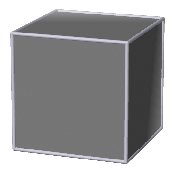

element =  Ag
number of vertices =  8
number of edges =  12
number of faces =  6
nearest neighbour distance = 2.70 Å
lattice constant = 3.82 Å
edge length = 0.38 nm
radius after volume = 0.24 nm
radius of the circumscribed sphere = 0.33 nm
radius of the inscribed sphere = 0.19 nm
area = 0.9 nm2
volume = 0.1 nm3
total number of atoms =  14
Dual polyhedron: octahedron


... and adding the upper layers
Duration : 00:00:00 013ms


Moments of inertia = 133555242.79 133555242.79 133555242.79 amu.Å2
Moments of inertia / M = 267.36 267.36 267.36 amu.Å2
Moments of inertia with mass=1/M = 267.36 267.36 267.36 Å2


 Principal Moments : I1=267.36, I2=267.36, I3=267.36
 NPR1 (I1/I3)      : 1.0000
 NPR2 (I2/I3)      : 1.0000
 Predicted Shape   : Spherical/Symmetric


 Rg = 20.0 nm


...

 Rg = 19.9 nm


Found:
  - 8 vertices
  - 12 simplices
  - Volume: 55.67 nm³
  - Area: 87.48 nm²
Duration : 00:00:00 002ms


1057 atoms lie in the plane(s)
Duration : 00:00:00 002ms


Diameter of the circumscribed sphere: 67.49 Å
Diameter of the inscribed sphere: 35.88 Å


  - Dimensions (Å): 66.14 x 66.14 x 66.14
  - Volume: 151.47 nm³
  - Surface: 137.41 nm²
  - Asphericity: 1.00
  - Max Radius found: 3.307 nm

  [Jmol Command to visualize the ellipsoid]:
  ellipsoid ID initial_structure_el AXES {0.000000 -23.382686 23.382686} {0.000000 -23.382686 -23.382686} {33.068112 0.000000 0.000000}; ellipsoid ID initial_structure_el CENTER {0.000 -0.000 1.152}; color $initial_structure_el [x919191] translucent 0.3;
  283 atoms removed, 4348 remaining.


In [3]:
from pyNanoMatBuilder import platonicNPs as pNP

NP = pNP.cube(
    crystalStructure = 'fcc',
    element = "Ag",
    Rnn = 2.7,
    size=4,
    shape="cube",
    skipSymmetryAnalyzis=True,
    noOutput=False,
)

pyNMBu.write("coords/cube.xyz",NP.NP)
planes=[
    # Pyramidal cavity: 4 tilted planes forming an inverted pyramid
    {
        'normal'  : [0, 1, 2],
        'distance': 10.0,             # distance from the center of mass, in Å
        'nRot'    : 4,                # 4-fold symmetry around z
        'rotAxis' : [0, 0, 1],
        'delete'  : 'above',
        'modeP'   : 'AND',            # inside ALL 4 planes → cavity
    },
]

NP.applySlicing(
    planes = planes,
    distance_unit='angstrom',
    mode='OR'
)
pyNMBu.write("coords/cube_concave_Slices.script",NP.jMolSlices)
pyNMBu.write("coords/cube_concave.xyz",NP.NP)
pyNMBu.write("coords/cube_concave.script",NP.jMolCS)

####  Cube with holes

In [ ]:
from pyNanoMatBuilder import platonicNPs as pNP

NP = pNP.cube(
    crystalStructure = 'fcc',
    element = "Ag",
    Rnn = 2.7,
    size=4,
    shape="cube",
    skipSymmetryAnalyzis=True,
    noOutput=False,
)

pyNMBu.write("coords/cube.xyz",NP.NP)
planes=[
    {
        'normal'  : [0, 1, 0],
        'distance': 4.0,
        'nRot'    : 4,
        'rotAxis' : [0, 0, 1],
        'delete'  : 'below',
        'modeP'   : 'AND',
    },
    {
        'normal'  : [1, 0, 0],
        'distance': 4.0,
        'nRot'    : 4,
        'rotAxis' : [0, 1, 0],
        'delete'  : 'below',
        'modeP'   : 'AND',
    },
    {
        'normal'  : [0, 0, 1],
        'distance': 4.0,
        'nRot'    : 4,
        'rotAxis' : [1, 0, 0],
        'delete'  : 'below',
        'modeP'   : 'AND',
    },]

NP.applySlicing(
    planes = planes,
    distance_unit='angstrom',
    mode='OR'
)
pyNMBu.write("coords/cube_holes_Slices.script",NP.jMolSlices)
pyNMBu.write("coords/cube_holes.xyz",NP.NP)
pyNMBu.write("coords/cube_holes.script",NP.jMolCS)

#### Cube with a surface cross

<div class="rqE">

A generalization to all square facets of the cube is given in [the tutorials notebook](pyNMB-tutorials.ipynb)
</div>

In [ ]:
from pyNanoMatBuilder import platonicNPs as pNP

NP = pNP.cube(
    crystalStructure = 'fcc',
    element = "Ag",
    Rnn = 2.7,
    size=4,
    shape="cube",
    skipSymmetryAnalyzis=True,
    noOutput=False,
)

planes=[
    # Groove along X: two opposite {100} planes close together
    {
        'normal'  : [1, 0, 0],
        'distance': 2.0,        # half-width of the groove in Å
        'nRot'    : 2,          # generates [1,0,0] and [-1,0,0]
        'rotAxis' : [0, 0, 1],
        'delete'  : 'above',
        'modeP'   : 'OR',       # atom removed if above ANY of the two planes
    },
    # Groove along Y: two opposite {010} planes close together
    {
        'normal'  : [0, 1, 0],
        'distance': 2.0,
        'nRot'    : 2,          # generates [0,1,0] and [0,-1,0]
        'rotAxis' : [0, 0, 1],
        'delete'  : 'above',
        'modeP'   : 'OR',
    },
    # Top cut: limits the depth of the cross groove
    {
        'normal'  : [0, 0, 1],
        'distance': 15.0,       # distance from center in Å
        'nRot'    : 1,
        'delete'  : 'above',
    },
]
NP.applySlicing(
    planes=planes,
    mode='AND',              # atom removed only if condemned by ALL groups
    distance_unit='Angstrom'
)
pyNMBu.write("coords/cube_1cross_Slices.script", NP.jMolSlices)
pyNMBu.write("coords/cube_1cross.xyz", NP.NP)
pyNMBu.write("coords/cube_1cross.script", NP.jMolCS)

## Mix two differents structures

### Basic documentation

# Load external xyz files

In [ ]:
import pyNanoMatBuilder as pyNMB
from pyphyschemtools import molView
NP = pyNMB.from_file("coords/bch.xyz", skipSymmetryAnalyzis=True)
molView(NP.NP,source='ase')
NP.peel_by_coordination(threshold_peeling=7, Rmax=2.9, noOutput=False)
molView(NP.NP,source='ase')

# Geometry optimization with ase


## Explanation of the `optimize` Function

<div class="intro">
    
The `optimize(calculator='EMT', optimizer='QN')` function is designed to perform structure optimization using the Effective Medium Theory (EMT) potential (https://ase-lib.org/ase/calculators/emt.html). This function supports the following standard EMT metals: Al, Cu, Ag, Au, Ni, Pd, and Pt.

### Parameters:
- **calculator**: Specifies the type of energy minimization calculator. Currently, only EMT is supported.
- **optimizer**: Defines the optimization algorithm. For example, 'QN' stands for Quasi-Newton optimization.

### Features:
1. **Structure Optimization**: The function computes the potential energy and optimizes the structure accordingly.
2. **Dimension Parameters**: After optimization, it calculates new dimension parameters such as:
    - vertices and surface sphere dimensions.
    - SASView-like dimensions.
    - Moments of Inertia (MOI).
3. **JMOL Scripts**: Generates JMOL scripts for visualization.

4. To simulate experimentally observed intermediate structures (e.g., less than a shell difference between two structures), the function introduces surface truncation methods to create defects in nanoparticles (NPs). These methods include:
    - **`peel_by_coordination(threshold_peeling=6, Rmax=2.9, noOutput=None)`**: Removes atoms based on their coordination number. This is an effective way to truncate specific regions, such as vertices.
    - **`peel_by_shifted_ellipsoid(shift_dist=2.5, noOutput=None)`**: Computes an ellipsoid matching the NP's size, shifts it by `shift_dist`, and truncates the NP based on the ellipsoid. This method is useful for removing specific sides of the NP.
</div>
<br>

<div class="rq">
    
*The dimension parameters mentionned above are also calculated when calling the peeling functions However, they are not always accurate, this is still an ongoing work.*
</div>

## Regular fcc octahedra

In [ ]:
from pyNanoMatBuilder import platonicNPs as pNP

from pyphyschemtools import molView

# Create the initial structure
fccOh = pNP.regfccOh("Au", 2.7, 5, skipSymmetryAnalyzis=False, noOutput=False)
mv = molView(fccOh.NP, source="ase")
pyNMBu.write("coords/fccOh.xyz", fccOh.NP)
# Note: It is also possible to call specific functions separately,
# But they are automatically called during the NP creation and optimization
# fccOh.vertices_surface_spheres()
# fccOh._update_sasview_dims_from_spheres()
# fccOh.get_ellipsoid_analysis()

# Do the optimization
fccOh.optimize() # The function will also recalculate the properties mentionned above and the JMOL script after the optimization
mv = molView(fccOh.NP_opt, source="ase")
pyNMBu.write("coords/fccOh_opt.xyz", fccOh.NP_opt)

## Regular dodecahedra

In [ ]:
from pyNanoMatBuilder import platonicNPs as pNP

from pyphyschemtools import molView

# Create your NP structure
rdd = pNP.regDD("Au",2.7,4)
mv = molView(rdd.NP, source="ase")
pyNMBu.write("coords/rdd.xyz", rdd.NP)
# It is also possible to call specific functions separately
# But they are automatically called durinng the NP creation and optimization
# rdd.vertices_surface_spheres()
# rdd._update_sasview_dims_from_spheres()
# rdd.get_ellipsoid_analysis()

# Do the optimization
rdd.optimize() # The function will also recalculate the properties mentionned above and the JMOL script after the optimization
mv = molView(rdd.NP_opt, source="ase")
pyNMBu.write("coords/rdd_opt.xyz", rdd.NP_opt)


# Apply "peeling" operations. Case of an fcc Au ellipsoid

<div class="intro">

**Steps to create an intermediate optimized peeled structure!**
1. Create the initial structure.
2. Peel the structure using the shifted ellipsoid and/or the coordination of the atoms.
3. Optimize the peeled structure.
</div>

<div class="rq">

**Warning:**

With this fcc CIF example (Au), the center of mass is not at 0, whereas with the hcp CIF (Ru), the translation operation places the center of mass at 0.
</div>



In [ ]:
from pyNanoMatBuilder import crystalNPs as cNP

# Create the initial structure with the shape of an ellipsoid (size = [2,2,4] nm)
AuNP = cNP.Crystal("Au fcc",shape='ellipsoid',size=[2,2,4], noOutput=True)
pyNMBu.write("coords/AuNP_ellipsoid.xyz", AuNP.NP)

# Create an intermediate structure with:
pyNMBu.centerTitle("Peeling the AuNP by shifted ellipsoid")
AuNP.peel_by_shifted_ellipsoid(shift_dist=7, noOutput=False) # shifted ellipsoid peeling
pyNMBu.centerTitle("Peeling the AuNP by coordination")
AuNP.peel_by_coordination(threshold_peeling=4, noOutput=False) # and then peel by coordination 

# Optimize the structure
pyNMBu.centerTitle("Optimize the peeled AuNP")
AuNP.optimize()

# Save the XYZ files and JMOL script of the optimized intermediate structure
pyNMBu.write("coords/AuNP_ellipsoid_opt_peeled.xyz", AuNP.NP_opt)
pyNMBu.write("coords/AuNP_opt_peeled.xyz", AuNP.NP_opt)
pyNMBu.write("coords/AuNP_opt_peeled.script", AuNP.jMolCS_opt)
pyNMBu.write("coords/AuNP_opt_peeled_CoreSurface.xyz", AuNP.NPcs_opt)

# Polydispersity

<div class="intro">

Real nanoparticle colloidal samples are never perfectly monodisperse, they always
exhibit a distribution of sizes, shapes, and sometimes structures. This
polydispersity has a direct impact on the measured SAXS/SANS signal, which
is a weighted sum of contributions from all particles in the sample.

The `NanoparticleDistribution` class provides tools to:
- **Fit** an experimental size distribution from (HR)TEM data
- **Build** theoretical distributions from fitted parameters (mean diameter,
  standard deviation, polydispersity index) using Gaussian or Schulz models
- **Analyze** the distribution: binned statistics, coverage, FWHM,
  characteristic sizes at μ ± nσ
- **Compute weights** for a set of target sizes, to be later used as input for
  a weighted sum of individual SAXS signals simulated with pyNanoMatBuilder
- **Plot** distributions and highlight some specific sizes

**Three instantiation modes are available**, depending on the available data:
- `from_TEM(sizes, counts)` — from experimental (HR)TEM size histograms
- `from_gaussian_params(mu, sigma)` — from fitted Gaussian parameters
- `from_polydispersity(mu, pd_pct, model)` — from mean diameter and
  polydispersity index (CV%), with Gaussian or Schulz model

**Several tools are provided:**

- `get_binned_statistics()` discretizes the distribution into fixed-width bins (default width = σ) and displays, for each bin:
    - **Count** — expected number of particles in the bin
    - **Area (%)** — fraction of the total population
    - **Ratio/Peak** — height relative to the distribution maximum (1.0 at μ)
    - **Norm. (1)** — normalized weight summing to 1.0 across all bins — this is the weight to use for a weighted SAXS sum

- `print_specific_proportions()` does the same but for user-defined target sizes. The **Norm. (1)** column gives the relative weight of each structure in the weighted SAXS sum.

- `plot()` automatically generates a publication-ready plot of the distribution.
  Specific sizes can be highlighted via `highlight_sizes`, each marker shows
  the diameter and its **Norm. (1)** weight in parentheses, as well as a label
  if provided.

</div>
<br>
<div class="rqE">


A polydispersity workflow can be directly connected to the pyNanoMatBuilder
structure generation pipeline: once the characteristic sizes and their
weights are identified, the corresponding atomic structures can be built,
optimized, and used to compute individual SAXS signals that are then summed
with the appropriate weights. This workflow is illustrated in detail in the
`pyNMB-tutorials.ipynb` notebook.
</div>


## Instantiate from particle size (HR)TEM data

In [ ]:
# Your specific data
counts = [1, 5, 32, 90, 110, 50, 17, 10]
sizes = [1.07, 1.24, 1.41, 1.58, 1.75, 1.92, 2.09, 2.26]

# Initialize and run
np_analysis = pyNMBu.NanoparticleDistribution.from_TEM(sizes=sizes, counts=counts)
np_analysis.fit()

print()
# Plot
np_analysis.plot()
print()
np_analysis.print_results()
print()
np_analysis.get_binned_statistics() #default bin size = sigma exp
np_analysis.get_binned_statistics(bin_width_nm=0.5) # user-defined bin size

## Instantiate directly from fitted gaussian sigma parameters

Model Type          : GAUSSIAN
Amplitude           : 2216 particles
Average Size (Mean) : 1.700 nm
Polydispersity (CV) : 10.59%
Std Deviation (σ)   : 0.180 nm
----------------------------------------
Theoretical Population Coverage (Dynamic):
  μ ± 1σ     ( 1.52-1.88  nm) : 68.3%
  μ ± 2σ     ( 1.34-2.06  nm) : 95.4%
  μ ± 3σ     ( 1.16-2.24  nm) : 99.7%


Size Range (nm)    | Count     | Area (%)  | Ratio/Peak  | Norm. (1)   
-----------------------------------------------------------------------
[ 1.07, 1.25 [     |         6 |      0.6% |      0.011 |      0.004
[ 1.25, 1.43 [     |        61 |      6.1% |      0.135 |      0.054
[ 1.43, 1.61 [     |       242 |     24.2% |      0.607 |      0.242
[ 1.61, 1.79 [     |       383 |     38.3% |      1.000 |      0.399
[ 1.79, 1.97 [     |       242 |     24.2% |      0.607 |      0.242
[ 1.97, 2.15 [     |        61 |      6.1% |      0.135 |      0.054
[ 2.15, 2.33 [     |         6 |      0.6% |      0.011 |      0.004
[ 2.33, 2.51 [     |         0 |      0.0% |      0.000 |      0.000
-----------------------------------------------------------------------
Total Covered      |      1000 |    100.0% |          - |      1.000


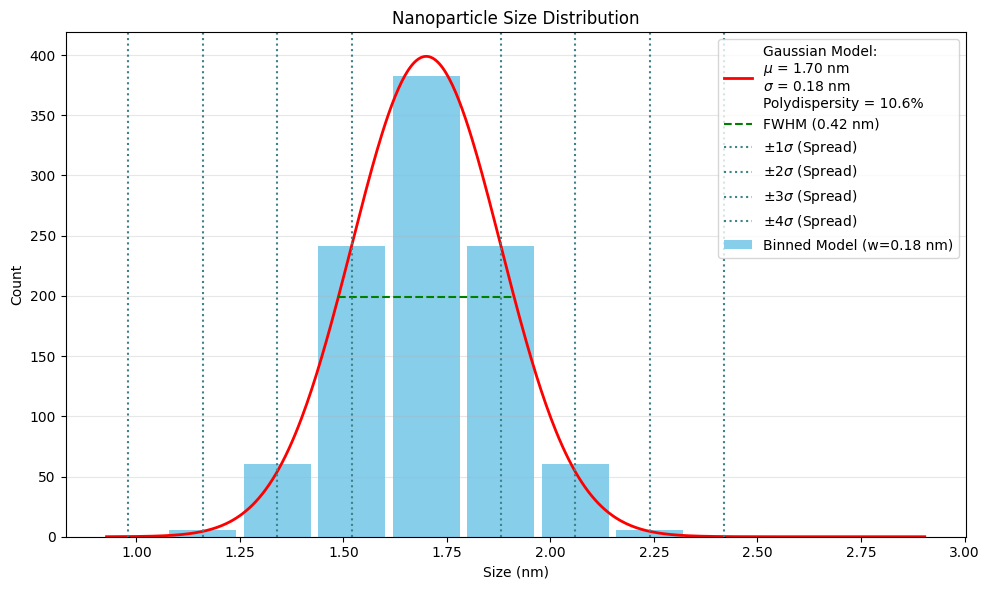

In [118]:
pyNMBu.centertxt("Plot the gaussian distribution and show the binned population, after the average diameter and sigma", size=16, bgc="red", weight="bold")

nd = pyNMBu.NanoparticleDistribution.from_gaussian_params(mu=1.70, sigma=0.18)
nd.print_results()
nd.get_binned_statistics()
nd.plot()

Label    | Diameter (nm)   | Ratio/Peak   | Est. Count   | Norm. (dist)   | Norm. (1)   
----------------------------------------------------------------------------------------
a        |         1.15 nm |      0.009   |         19   |       0.0034   |     0.0048
b        |         1.50 nm |      0.539   |       1196   |       0.2152   |     0.3001
c        |         1.70 nm |      1.000   |       2216   |       0.3990   |     0.5563
d        |         2.00 nm |      0.249   |        553   |       0.0995   |     0.1387
e        |         2.50 nm |      0.000   |          0   |       0.0000   |     0.0000
----------------------------------------------------------------------------------------


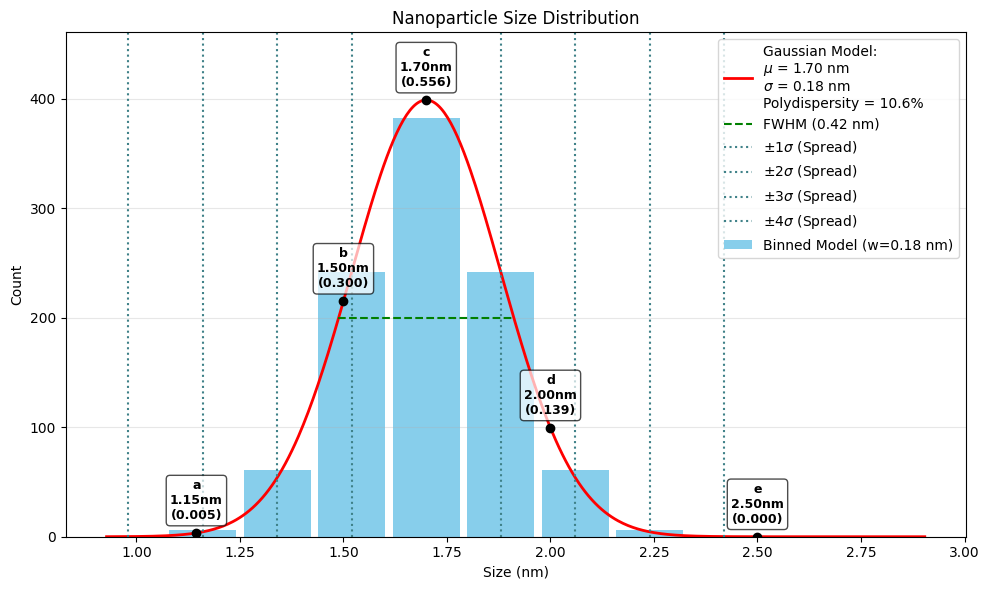

In [119]:
pyNMBu.centertxt("Show specific proportions on the plot", size=16, bgc="red", weight="bold")

my_targets = [1.145, 1.5, 1.700, 2.0, 2.5]
labels = ["a", "b", "c", "d", "e"]
nd.print_specific_proportions(my_targets, labels)

# 3. Plot with highlights (if updated)
nd.plot(highlight_sizes=[my_targets, labels])

## Instantiate directly from polydispersity parameters, assuming a gaussian distribution

Model Type          : GAUSSIAN
Amplitude           : 1395 particles
Average Size (Mean) : 2.600 nm
Polydispersity (CV) : 11.00%
Std Deviation (σ)   : 0.286 nm
----------------------------------------
Theoretical Population Coverage (Dynamic):
  μ ± 1σ     ( 2.31-2.89  nm) : 68.3%
  μ ± 2σ     ( 2.03-3.17  nm) : 95.4%
  μ ± 3σ     ( 1.74-3.46  nm) : 99.7%


Size Range (nm)    | Count     | Area (%)  | Ratio/Peak  | Norm. (1)   
-----------------------------------------------------------------------
[ 1.23, 1.78 [     |         2 |      0.2% |      0.001 |      0.000
[ 1.78, 2.33 [     |       166 |     16.6% |      0.157 |      0.120
[ 2.33, 2.88 [     |       664 |     66.4% |      1.000 |      0.760
[ 2.88, 3.42 [     |       166 |     16.6% |      0.157 |      0.120
[ 3.42, 3.97 [     |         2 |      0.2% |      0.001 |      0.000
-----------------------------------------------------------------------
Total Covered      |      1000 |    100.0% |          - |      1.000


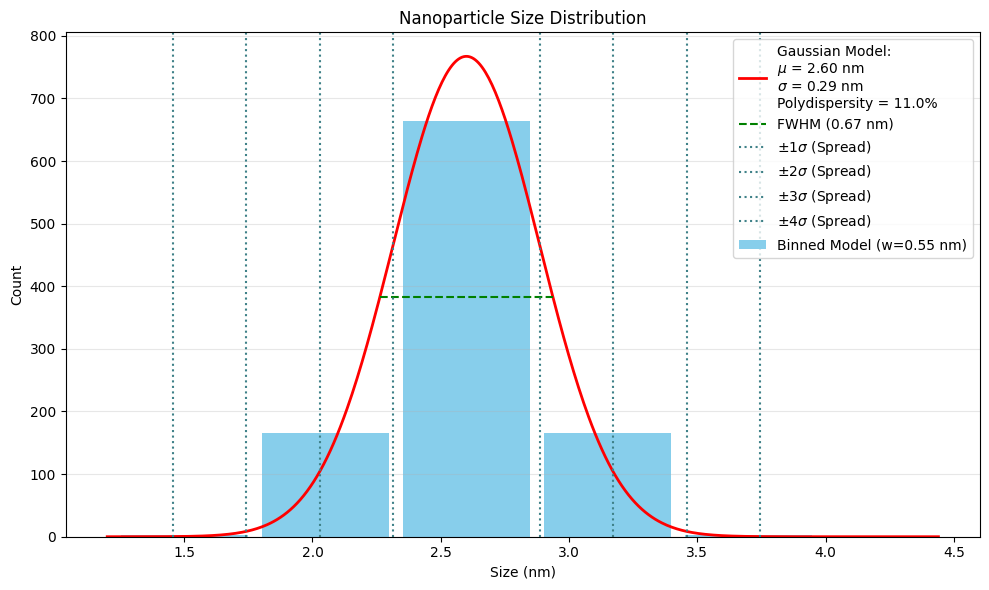

In [120]:
pyNMBu.centertxt("Plot the gaussian distribution and show the binned population, after the average diameter and polydispersity parameters", size=16, bgc="red", weight="bold")

nd = pyNMBu.NanoparticleDistribution.from_polydispersity(mu=2.60, pd_pct=11)
nd.print_results()
nd.get_binned_statistics(bin_width_nm=0.55)
nd.plot()

Label    | Diameter (nm)   | Ratio/Peak   | Est. Count   | Norm. (dist)   | Norm. (1)   
----------------------------------------------------------------------------------------
a        |         1.70 nm |      0.007   |         10   |       0.0054   |     0.0035
b        |         2.00 nm |      0.111   |        154   |       0.0841   |     0.0552
c        |         2.50 nm |      0.941   |       1312   |       0.7148   |     0.4689
d        |         2.70 nm |      0.941   |       1312   |       0.7148   |     0.4689
e        |         3.50 nm |      0.007   |         10   |       0.0054   |     0.0035
----------------------------------------------------------------------------------------


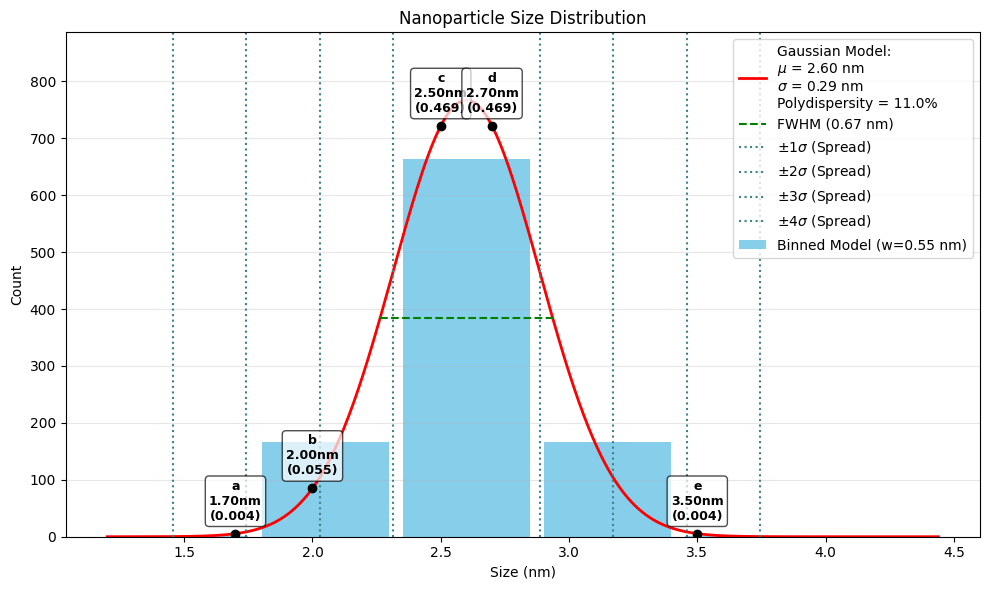

['a', 'b', 'c', 'd', 'e']
[0.00352586 0.05519492 0.46887668 0.46887668 0.00352586]


In [121]:
pyNMBu.centertxt("Show specific proportions on the plot", size=16, bgc="red", weight="bold")

my_targets = [1.70, 2.0, 2.5, 2.7, 3.5]
labels = ["a", "b", "c", "d", "e"]
nd.print_specific_proportions(my_targets, labels)

# 3. Plot with highlights (if updated)
nd.plot(highlight_sizes=[my_targets, labels])

# it is possible to use the proportions for later use
data = nd.get_proportions(my_targets, labels)
print(data["labels"])
print(data['norms_relative'])

## Schulz distribution

<div class="intro">

The `NanoparticleDistribution` class also supports the Schulz distribution
as an alternative to the Gaussian model, via the `model` parameter of
`from_polydispersity()`:

```python
nd = NanoparticleDistribution.from_polydispersity(mu=2.60, pd_pct=11, model='schulz')
```

<br>
The Schulz distribution is skewed towards larger values and is better suited than a Gaussian for nanoparticle size distributions obtained from SAXS/SANS experiments.

All existing methods (`print_results`, `get_binned_statistics`, `get_proportions`, `plot`, ...) are fully compatible with both models.

See the [Polydispersity & Orientational Distributions](https://www.sasview.org/docs/user/qtgui/Perspectives/Fitting/pd/polydispersity.html) section in the SasView documentation.
</div>

Model Type          : SCHULZ
Amplitude           : 1000 particles
Average Size (Mean) : 2.600 nm
Polydispersity (CV) : 11.00%


Size Range (nm)    | Count     | Area (%)  | Ratio/Peak  | Norm. (1)   
-----------------------------------------------------------------------
[ 1.23, 1.78 [     |         1 |      0.1% |      0.000 |      0.000
[ 1.78, 2.33 [     |       168 |     16.8% |      0.146 |      0.112
[ 2.33, 2.88 [     |       665 |     66.5% |      1.000 |      0.763
[ 2.88, 3.42 [     |       163 |     16.3% |      0.163 |      0.124
[ 3.42, 3.97 [     |         4 |      0.4% |      0.002 |      0.002
-----------------------------------------------------------------------
Total Covered      |      1000 |    100.0% |          - |      1.000


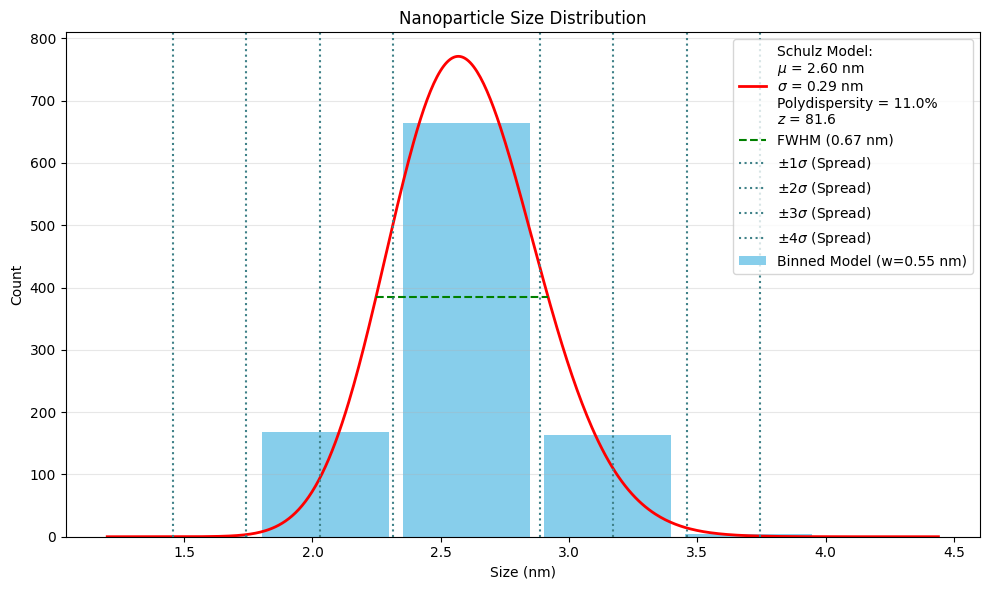

Label    | Diameter (nm)   | Ratio/Peak   | Est. Count   | Norm. (dist)   | Norm. (1)   
----------------------------------------------------------------------------------------
a        |         1.70 nm |      0.002   |          2   |       0.0017   |     0.0011
b        |         2.00 nm |      0.095   |         95   |       0.0728   |     0.0479
c        |         2.50 nm |      0.977   |        977   |       0.7449   |     0.4896
d        |         2.70 nm |      0.907   |        907   |       0.6919   |     0.4548
e        |         3.50 nm |      0.013   |         13   |       0.0100   |     0.0065
----------------------------------------------------------------------------------------


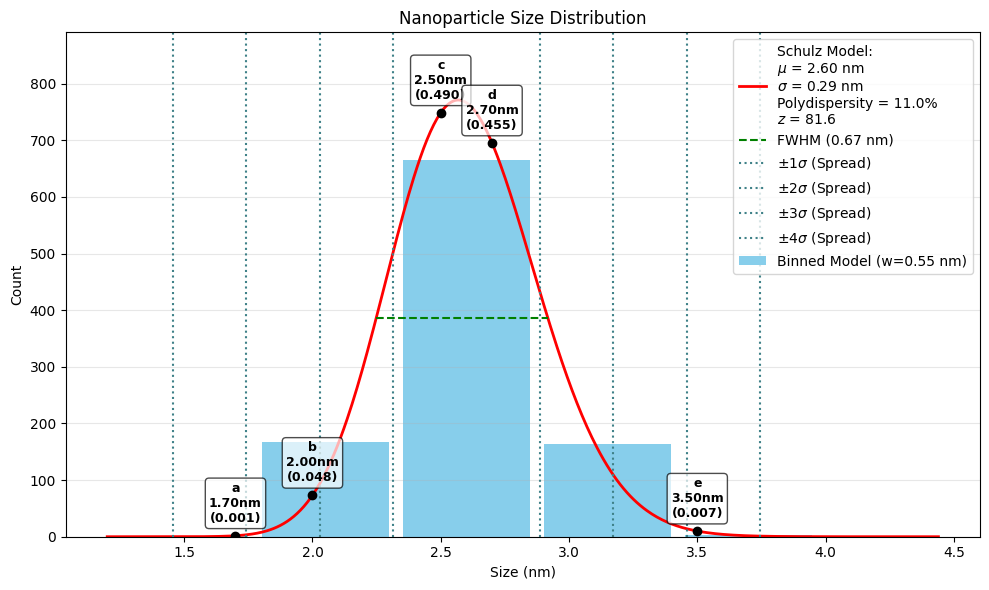

['a', 'b', 'c', 'd', 'e']
[0.00114514 0.04786607 0.48964542 0.4548001  0.00654327]


In [122]:
pyNMBu.centertxt("Plot the Schulz distribution and show the binned population, after the average diameter and polydispersity parameters", size=16, bgc="red", weight="bold")

nd = pyNMBu.NanoparticleDistribution.from_polydispersity(mu=2.60, pd_pct=11, model="schulz")
nd.print_results()
nd.get_binned_statistics(bin_width_nm=0.55)
nd.plot()

pyNMBu.centertxt("Show specific proportions on the plot", size=16, bgc="red", weight="bold")

my_targets = [1.70, 2.0, 2.5, 2.7, 3.5]
labels = ["a", "b", "c", "d", "e"]
nd.print_specific_proportions(my_targets, labels)

# 3. Plot with highlights (if updated)
nd.plot(highlight_sizes=[my_targets, labels])

# it is possible to use the proportions for later use
data = nd.get_proportions(my_targets, labels)
print(data["labels"])
print(data['norms_relative'])

# Miscellaneous

## List all cif files available in the database

In [ ]:
from pyNanoMatBuilder import data

display(data.pyNMBcif.CIFdf)
pyNMBu.listCifsOfTheDatabase()

## Find all symmetry-equivalent planes, by all rotations of a symmetry group

- [Cubic crystal system](https://en.wikipedia.org/wiki/Cubic_crystal_system)
- [Hexagonal crystal family](https://en.wikipedia.org/wiki/Hexagonal_crystal_family)

In [8]:
from pymatgen.symmetry.groups import SpaceGroup

import pyNanoMatBuilder as pyNMB

# hcp
plane = [1,0,0]
cs = "hcp"
group=194
pyNMB.centerTitle(f"Crystalline Structures = {cs}. Space Group {group}. Plane = {plane}")
print(pyNMBu.print_spacegroup_info(group))
print()
print(pyNMBu.get_equivalent_miller_indices(group, plane))

# fcc
plane = [1,1,1]
cs = "fcc"
group=225
pyNMB.centerTitle(f"Crystalline Structures = {cs}. Space Group {group}. Plane = {plane}")
print(pyNMBu.print_spacegroup_info(group))
print()
print(pyNMBu.get_equivalent_miller_indices(group, plane))

--- Details for Space Group 194 ---
Symbol (Name)      : P6_3/mmc
Crystal System     : hexagonal
Number of Ops      : 24

[[ 0 -1  0]
 [ 1 -1  0]
 [-1  0  0]
 [ 1  0  0]
 [-1  1  0]
 [ 0  1  0]]


--- Details for Space Group 225 ---
Symbol (Name)      : Fm-3m
Crystal System     : cubic
Number of Ops      : 192

[[-1 -1 -1]
 [ 1 -1 -1]
 [-1  1 -1]
 [ 1  1 -1]
 [-1 -1  1]
 [ 1 -1  1]
 [-1  1  1]
 [ 1  1  1]]


## Calculate angles between planes

### Calculate the angle between two cristallographic planes or directions

In [4]:
from pyNanoMatBuilder import crystalNPs as cyNP
AuNP = cyNP.Crystal("Au fcc",
                    thresholdCoreSurface=0.5,
                    skipSymmetryAnalyzis= True,
                    postAnalyzis=False,
                    jmolCrystalShape=False,
                    aseView= False,
                    noOutput=True,
                   )

angle = AuNP.crystallographic_angle([1,1,0], [1,1,5],
                                   type1='direction', type2='plane', noOutput=False)

Change of basis
( 1.00  1.00  0.00)B > ( 4.08  4.08  0.00)C
Change of basis
( 0.06  0.06  0.30)B > ( 0.25  0.25  1.23)C
Angle between direction [1 1 0] and plane (1 1 5) : 15.7932°


### Computes all pairwise dihedral angles between a list of crystallographic planes for any crystal system

In [30]:
NP = cyNP.Crystal("FeCo bcc", noOutput=True)
print(pyNMBu.print_spacegroup_info(NP.ucSG_number))
planes = [[3,1,1], [3,1,-1], [3,-1,1], [1,3,1], [1,1,1], [1,1,0]]
_ = NP.angles_between_planes(planes)

--- Details for Space Group 221 ---
Symbol (Name)      : Pm-3m
Crystal System     : cubic
Number of Ops      : 48


,(311),(31-1),(3-11),(131),(111),(110)
(311),—,35.10°,35.10°,50.48°,29.50°,31.48°
(31-1),35.10°,—,50.48°,62.96°,58.52°,31.48°
(3-11),35.10°,50.48°,—,84.78°,58.52°,64.76°
(131),50.48°,62.96°,84.78°,—,29.50°,31.48°
(111),29.50°,58.52°,58.52°,29.50°,—,35.26°
(110),31.48°,31.48°,64.76°,31.48°,35.26°,—


## Generate and visualize a slab

In [ ]:
AuNP = cyNP.Crystal("Au fcc",
                    thresholdCoreSurface=0.5,
                    skipSymmetryAnalyzis= True,
                    postAnalyzis=False,
                    jmolCrystalShape=False,
                    aseView= False,
                    noOutput=False,
                   )
slab = AuNP.generateSlab([1,1,7], size_a=2.0, size_b=2.0, min_thickness=10.0, backend="ase")
print("cell[0] (a) =", slab.NP.cell[0])
print("cell[1] (b) =", slab.NP.cell[1])
print("cell[2] (c) =", slab.NP.cell[2])
print("scaled positions min/max:")
s = slab.NP.get_scaled_positions()
print("  a:", s[:,0].min(), s[:,0].max())
print("  b:", s[:,1].min(), s[:,1].max())
print("  c:", s[:,2].min(), s[:,2].max())
script = slab.defSlabShapeForJMol([1,1,5], offset=0)
pyNMBu.write("coords/slab117.cif",slab.NP)
pyNMBu.write("coords/slab117.script",script)

from pyphyschemtools import molView
molView(slab.NP, source='ase', w=800, h=800)

## Save the coordination numbers in a dat file for jmol plots

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP


RuNP = cyNP.Crystal("Ru hcp",
                    shape='Wulff: hcpsph1',
                    noOutput=True,sizesWulff=[2],
                    threshold=1e-3,
                    thresholdCoreSurface=2,
                    postAnalyzis=True,
                    jmolCrystalShape=True)
pyNMBu.write("coords/Ruhcp.xyz", RuNP.NP)
pyNMBu.saveCN4JMol(RuNP.NP,save2="coords/Ruhcp_CN.dat",Rmax=3.0)

## Interplanar spacing

In [ ]:
import numpy as np
from pyNanoMatBuilder import crystalNPs as cyNP

pyNMBu.centerTitle("Hardcoded data")
plane = [1, 3, 7]
pyNMBu.centertxt("CUB. expected value for [1, 3, 7] = & a=b=c=2.71: 0.353",size=14,weight="bold")
unitcell = [2.71, 2.71, 2.71, 90, 90, 90]
print('CUB',pyNMBu.interPlanarSpacing(plane, unitcell,'CUB'))
print('TRI',pyNMBu.interPlanarSpacing(plane, unitcell,'TRI'))

pyNMBu.centertxt("HEX. expected value for [1, 3, 7] = & a=b=c=2.71, gamma=120: 0.455",size=14,weight="bold")
unitcell = [2.71, 2.71, 2.71*1.64, 90, 90, 120]
print('HEX',pyNMBu.interPlanarSpacing(plane, unitcell,'HEX'))
print('TRI',pyNMBu.interPlanarSpacing(plane, unitcell,'TRI'))

pyNMBu.centertxt("TRH. expected value for [1, 3, 7] = & a=b=c=2.71 & alpha=60: 0.357",size=14,weight="bold")
unitcell = [2.71, 2.71, 2.71, 60, 60, 60]
print('TRH',pyNMBu.interPlanarSpacing(plane, unitcell,'TRH'))
print('TRI',pyNMBu.interPlanarSpacing(plane, unitcell,'TRI'))

pyNMBu.centertxt("TET. expected value for [1, 3, 7] = & a=b=2.71 & c=2.87: 0.370",size=14,weight="bold")
unitcell = [2.71, 2.71, 2.87, 90, 90, 90]
print('TET',pyNMBu.interPlanarSpacing(plane, unitcell,'TET'))
print('TRI',pyNMBu.interPlanarSpacing(plane, unitcell,'TRI'))

pyNMBu.centertxt("ORC. expected value for [1, 3, 7] = &  a=2.71, b=2.87, c=3.12 : 0.400",size=14,weight="bold")
unitcell = [2.71, 2.87, 3.12, 90, 90, 90]
print('ORC',pyNMBu.interPlanarSpacing(plane, unitcell,'ORC'))
print('TRI',pyNMBu.interPlanarSpacing(plane, unitcell,'TRI'))

pyNMBu.centertxt("MCL. expected value for [1, 3, 7] = & a=2.71, b=2.87, c=3.12 & alpha=90, beta=120, gamma=90: 0.332",size=14,weight="bold")
unitcell = [2.71, 2.87, 3.12, 90, 120, 90]
print('MCL',pyNMBu.interPlanarSpacing(plane, unitcell,'MCL'))
print('TRI',pyNMBu.interPlanarSpacing(plane, unitcell,'TRI'))

pyNMBu.centertxt("TRI. expected value for [1, 3, 7] = & a=2.71, b=2.87, c=3.12 & alpha=33, beta=54, gamma=22: 0.296",size=14,weight="bold")
unitcell = [2.71, 2.87, 3.12, 33, 54, 22]
print('TRI',pyNMBu.interPlanarSpacing(plane, unitcell,'TRI'))

pyNMBu.centerTitle("From cif file")

pyNMBu.centertxt("Aufcc, distance between [1,1,1] planes",size=14,weight="bold")
AuNP = cyNP.Crystal("Au fcc", noOutput=True)
d = AuNP.interPlanarSpacing([1, 1, 1], noOutput=False)
d_exact = AuNP.ucUnitcell[0]/np.sqrt(3)
print(f"{d_exact=:.4f} Å. Exact value same as numerical value ? {d_exact.round(14)==d.round(14)}")

## plane <-> direction conversion

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder.utils.crystals import direction_to_plane, plane_to_direction

RuNP = cyNP.Crystal("Ru hcp",
                    noOutput=True)
hkl = direction_to_plane(RuNP, [1, 0, 0])
print(hkl)
hkl = direction_to_plane(RuNP, [1, 0, 0], cartesian=True)
print(hkl)
uvw = plane_to_direction(RuNP, [2, -1, 0])
print(uvw)


In [ ]:
pyNMB.end()

# End